## RL Book Graphics 2
- Made descent progress on the supporting code, bringing that over here for nice uniformity, and doing the more complex renders we need for the book. 

In [1]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
from pathlib import Path as FilePath
from matplotlib.path import Path
from matplotlib.markers import MarkerStyle
from matplotlib.patches import FancyBboxPatch, Circle

CHILL_BROWN="#948979"
FRESH_TAN="#f4ebd9"
ORANGE='#eb8423'
LT_BLUE='#5badb6'
GREEN='#419c52'
RED='#d73b2f'
PINK='#ed5e78'

DATA = FilePath("/Users/stephen/ai_book_vol_2/chapters/02-reinforcement-learning/data")  # Chapter data lives next to the notebook

import matplotlib.colors as mcolors
cmap = mcolors.LinearSegmentedColormap.from_list("blue_orange", [LT_BLUE, ORANGE], N=256)

In [2]:
HACKIN_DIR = '/Volumes/hot_1/Stephencwelch Dropbox/welch_labs/rl_1/hackin'
SAVE_DIR = '/Volumes/hot_1/Stephencwelch Dropbox/welch_labs/ai_book_vol_2/2_reinforcement_learning/graphics'

# HACKIN_DIR = '/Users/stephen/Library/CloudStorage/Dropbox-Stephencwelch/welch_labs/rl_1/hackin'
# SAVE_DIR = '/Users/stephen/Library/CloudStorage/Dropbox-Stephencwelch/welch_labs/ai_book_vol_2/2_reinforcement_learning/graphics/'

In [3]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
})

In [4]:
def style_ax(ax, color=CHILL_BROWN):
    ax.spines[:].set_color(color)
    ax.tick_params(colors=color, which='both')
    ax.xaxis.label.set_color(color)
    ax.yaxis.label.set_color(color)
    ax.title.set_color(color)

def style_cbar(cbar, color=CHILL_BROWN):
    cbar.outline.set_edgecolor(color)
    cbar.ax.tick_params(colors=color, which='both')
    cbar.ax.yaxis.label.set_color(color)
    cbar.ax.xaxis.label.set_color(color)
    cbar.ax.title.set_color(color)

In [5]:
def arrow_path(direction=1, shaft_w=0.28, head_w=0.9, head_len=0.9, total_len=2.0):
    hl = head_len; sw = shaft_w/2; hw = head_w/2; L = total_len/2
    verts = np.array([
        (-L,  sw), (L-hl,  sw), (L-hl,  hw), (L, 0),
        (L-hl, -hw), (L-hl, -sw), (-L, -sw), (-L, sw),
    ]) * direction   # direction=-1 mirrors -> left arrow
    codes = [Path.MOVETO] + [Path.LINETO]*6 + [Path.CLOSEPOLY]
    return Path(verts, codes)

RIGHT_ARROW = MarkerStyle(arrow_path(+1))
LEFT_ARROW  = MarkerStyle(arrow_path(-1))

CART_W, CART_H, POLE_LEN, WHEEL_R = 0.5, 0.26, 1.0, 0.09
X_LIM = (-2.4, 2.4)

def draw_cartpole(ax, cart_x, pole_theta, action=None, y0=0.0,
                  setup_axes=True, track=True, arrow_size=420, arrow_dy=-0.32, stroke_color='k', fill_color='w'):
    """Draw one cart-pole state with its track baseline at y=y0."""
    if setup_axes:
        ax.set_xlim(*X_LIM); ax.set_ylim(y0-0.55, y0+1.75)
        ax.set_aspect('equal'); ax.axis('off')
    if track:
        ax.plot(X_LIM, [y0, y0], color=CHILL_BROWN, lw=1.5, zorder=1)
    cart_y = y0 + WHEEL_R*2
    for dx in (-CART_W*0.3, CART_W*0.3):
        ax.add_patch(Circle((cart_x+dx, y0+WHEEL_R), WHEEL_R, color=stroke_color, zorder=3))
    ax.add_patch(FancyBboxPatch((cart_x-CART_W/2, cart_y), CART_W, CART_H,
                 boxstyle="round,pad=0.02,rounding_size=0.05",
                 fc=fill_color, ec=stroke_color, lw=2.0, zorder=4))
    px, py = cart_x, cart_y + CART_H
    ax.plot([px, px + POLE_LEN*np.sin(pole_theta)],
            [py, py + POLE_LEN*np.cos(pole_theta)],
            color=stroke_color, lw=3, solid_capstyle='round', zorder=5)
    ax.add_patch(Circle((px, py), 0.07, color=stroke_color, zorder=6))
    if action is not None:   # needs RIGHT_ARROW / LEFT_ARROW defined
        ax.scatter([cart_x], [y0+arrow_dy],
                   marker=(RIGHT_ARROW if action==1 else LEFT_ARROW), s=arrow_size,
                   color=(YELLOW if action==1 else BLUE), linewidths=0, zorder=5)


def episode_frame_indices(n_steps, n_plots):
    """Evenly spaced step indices, always including the first and last step."""
    return np.unique(np.round(np.linspace(0, n_steps-1, n_plots)).astype(int))


def draw_episode(cart_xs, pole_thetas, n_plots, actions=None, spacing=1.6,
                 ax=None, fig_width=3.0, show_actions=False, label_steps=False,
                 pad_top=1.75, pad_bottom=0.55, top_down=True, **cartpole_kwargs):
    """
    Stack n_plots cart-pole states vertically in a single axis.

    spacing   : vertical distance between track baselines, in data units
                (the cart+pole is ~1.4 tall, so spacing < 1.4 will overlap).
    top_down  : first step at the top (True) or bottom (False).
    Returns fig, ax, idx (the step indices drawn), ys (baseline y of each frame).
    """
    cart_xs, pole_thetas = np.asarray(cart_xs), np.asarray(pole_thetas)
    idx = episode_frame_indices(len(cart_xs), n_plots)
    ys = -spacing*np.arange(len(idx)) if top_down else spacing*np.arange(len(idx))

    if ax is None:
        x_range = X_LIM[1]-X_LIM[0]
        y_range = spacing*(len(idx)-1) + pad_top + pad_bottom
        fig = plt.figure(figsize=(fig_width, fig_width*y_range/x_range))
        ax = fig.add_subplot(111)
    else:
        fig = ax.figure

    for t, y0 in zip(idx, ys):
        a = actions[t] if (show_actions and actions is not None) else None
        draw_cartpole(ax, cart_xs[t], pole_thetas[t], action=a, y0=y0,
                      setup_axes=False, **cartpole_kwargs)
        if label_steps:
            ax.text(X_LIM[0]-0.15, y0+0.1, f't={t}', ha='right', va='bottom',
                    color=CHILL_BROWN, fontsize=8)

    ax.set_xlim(*X_LIM)
    ax.set_ylim(ys.min()-pad_bottom, ys.max()+pad_top)
    ax.set_aspect('equal'); ax.axis('off')
    return fig, ax, idx, ys

In [6]:
with open(DATA / "sw_cartpole_game.json") as f: 
    data = json.load(f)

VEL_SCALE = 10   # divide velocities by 10 -> feature scales comparable, ~isotropic parameter space
obs = torch.tensor(data["episodes"][0]["observations"]) 
X = obs[:, 2:4] * 180/np.pi # Here we'll just use pole angle and pole angular velocity, and use degrees
X[:,1] = X[:,1] / VEL_SCALE # Scale pole angular velocity
y = torch.tensor(data['episodes'][0]['actions'])

In [7]:
X.shape, y.shape #This game is 66 steps long

(torch.Size([66, 2]), torch.Size([66]))

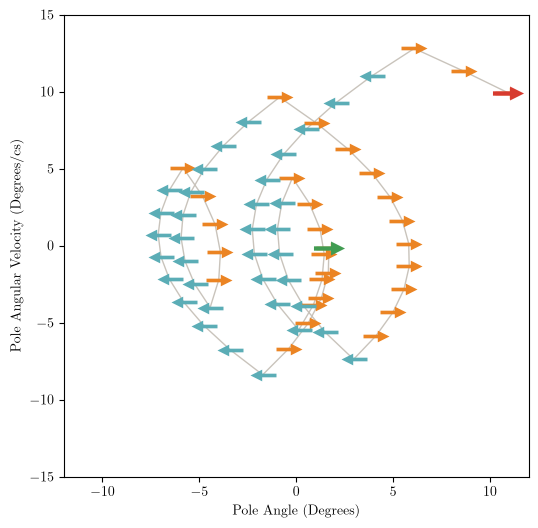

In [8]:
fig=plt.figure(0, (6,6))
ax=fig.add_subplot(111)

m = (y == 1)
plt.plot(X[:,0], X[:,1], color=CHILL_BROWN, lw=1, alpha=0.5, zorder=-10)
ax.scatter(X[m, 0],  X[m, 1],  marker=RIGHT_ARROW, s=350, color=ORANGE, alpha=1.0, linewidths=0)
ax.scatter(X[~m, 0], X[~m, 1], marker=LEFT_ARROW,  s=350, color=LT_BLUE,   alpha=1.0, linewidths=0)
ax.scatter(X[0, 0],  X[0, 1],  marker= RIGHT_ARROW if y[0]==1 else LEFT_ARROW, s=500, color=GREEN, alpha=1.0, linewidths=0) #First step green
ax.scatter(X[-1, 0],  X[-1, 1],  marker= RIGHT_ARROW if y[-1]==1 else LEFT_ARROW, s=500, color=RED, alpha=1.0, linewidths=0) #Last step red
plt.xlabel('Pole Angle (Degrees)'); plt.ylabel('Pole Angular Velocity (Degrees/cs)')
plt.xlim([-12, 12]); plt.ylim([-15, 15])

plt.savefig(SAVE_DIR+'/state_space_1b.svg')

- Ok noodling in illustrator here, would like to render out separate `draw_cartpole` svgs for each each step, then I'll use a few for callouts from the state space diagram. 

In [9]:
ep = data["episodes"][0]
obs_np = np.asarray(ep["observations"])   # columns: cart_x, cart_v, pole_theta, pole_omega
acts   = np.asarray(ep["actions"])

FRAME_DIR = FilePath(SAVE_DIR) / "cartpole_frames"
FRAME_DIR.mkdir(parents=True, exist_ok=True)

SHOW_ACTIONS = False   # set True to draw the left/right arrow under the cart

for t in tqdm(range(len(obs_np))):
    fig = plt.figure(figsize=(3.0, 1.45))   # matches X_LIM (4.8 wide) x (0.55+1.75 tall) at equal aspect
    ax = fig.add_subplot(111)
    draw_cartpole(ax, obs_np[t, 0], obs_np[t, 2],
                  action=acts[t] if SHOW_ACTIONS else None)
    fig.savefig(FRAME_DIR / f"step_{t:02d}.svg", bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)

print(f"Saved {len(obs_np)} frames to {FRAME_DIR}")

100%|████████████████████████████████████████████████| 66/66 [00:00<00:00, 158.26it/s]

Saved 66 frames to /Volumes/hot_1/Stephencwelch Dropbox/welch_labs/ai_book_vol_2/2_reinforcement_learning/graphics/cartpole_frames


Ok ok ok ok ok ok ok ok now we need network overlay on top of state space. 

In [10]:
class Pi(nn.Module):
    """Two-parameter policy: logit = theta1 * pole_angle + theta2 * pole_ang_velocity."""
    def __init__(self):
        super().__init__()
        self.theta = nn.Parameter(torch.zeros(2))  # [theta1, theta2] -> uniform random policy at init

    def forward(self, x):
        logit = x @ self.theta.to(x.dtype)         # compute at the precision of the input; we'll need double precision later
        return torch.sigmoid(logit)

In [11]:
agent=Pi()

In [12]:
# #We can pass in a test state (angle=1, angular vel=2) and get the agent's output before training
# with torch.no_grad():
#     yhat=agent(torch. tensor([1,2]))
# yhat

In [13]:
ANG_LIM = (-15, 15) #Limits for the network output visualization
VEL_LIM = (-15, 15)   

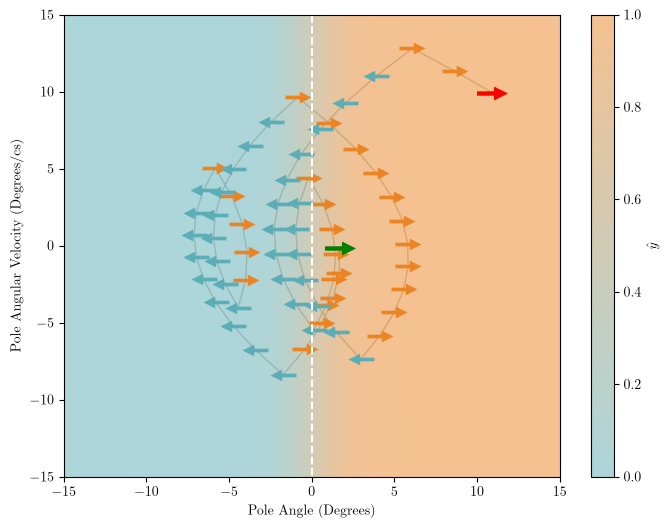

In [14]:
fig=plt.figure(0, (8,6))
ax=fig.add_subplot(111)

A, V = np.meshgrid(np.linspace(*ANG_LIM, 160), np.linspace(*VEL_LIM, 160))
with torch.no_grad():
    agent.theta[:] = torch.tensor([1.0, 0])
    grid = torch.tensor(np.stack([A.ravel(), V.ravel()], axis=1), dtype=torch.float32)  # (160*160, 2)
    yhat_grid = agent(grid).reshape(A.shape).numpy()                                     # back to (160, 160)

im = ax.imshow(yhat_grid, origin='lower', vmin=0, vmax=1, cmap=cmap,
               extent=[*ANG_LIM, *VEL_LIM], aspect='auto', alpha=0.5)
ax.contour(A, V, yhat_grid, levels=[0.5], colors='w', linestyles='--', linewidths=1.5)
plt.colorbar(im, label='$\hat{y}$')

m = (y == 1)
plt.plot(X[:,0], X[:,1], color=CHILL_BROWN, lw=1, alpha=0.5, zorder=-10)
ax.scatter(X[m, 0],  X[m, 1],  marker=RIGHT_ARROW, s=350, color=ORANGE, alpha=1.0, linewidths=0)
ax.scatter(X[~m, 0], X[~m, 1], marker=LEFT_ARROW,  s=350, color=LT_BLUE,   alpha=1.0, linewidths=0)
ax.scatter(X[0, 0],  X[0, 1],  marker= RIGHT_ARROW if y[0]==1 else LEFT_ARROW, s=500, color='g', alpha=1.0, linewidths=0) #First step green
ax.scatter(X[-1, 0],  X[-1, 1],  marker= RIGHT_ARROW if y[-1]==1 else LEFT_ARROW, s=500, color='r', alpha=1.0, linewidths=0) #Last step red
plt.xlabel('Pole Angle (Degrees)'); plt.ylabel('Pole Angular Velocity (Degrees/cs)')

plt.savefig(SAVE_DIR+'/state_space_with_overlay_1.svg')

Ok dope, now I want to make a nice table that shows how the L1 loss is computed. The table columns should be: step (starting at 1), x1, x2, y, yhat, |y-yhat|. I want a configurable number of space between entries, no commas, and zero padding so everything has two decimal places. I'll copy and past this into illustrator. 

In [15]:
SEP = 4          # minimum spaces between columns
N_STEPS = None   # e.g. 10 to only show the first 10 rows; None for all 66

with torch.no_grad():
    yhat = agent(X).squeeze()

n = len(X) if N_STEPS is None else N_STEPS
rows = [['step', 'x1', 'x2', 'y', 'yhat', '|y-yhat|']]
for t in range(n):
    rows.append([
        f'{t+1}',
        f'{X[t,0]:.2f}',
        f'{X[t,1]:.2f}',
        f'{int(y[t])}',
        f'{yhat[t]:.2f}',
        f'{abs(y[t]-yhat[t]):.2f}',
    ])

widths = [max(len(r[c]) for r in rows) for c in range(len(rows[0]))]
gap = ' ' * SEP
table = '\n'.join(gap.join(cell.rjust(w) for cell, w in zip(r, widths)) for r in rows)
print(table)
print(f'\nmean L1 loss = {abs(y[:n]-yhat[:n]).mean():.2f}')

step       x1       x2    y    yhat    |y-yhat|
   1     1.69    -0.16    1    0.84        0.16
   2     1.66    -1.78    1    0.84        0.16
   3     1.30    -3.41    1    0.79        0.21
   4     0.62    -5.04    1    0.65        0.35
   5    -0.39    -6.70    1    0.40        0.60
   6    -1.73    -8.39    0    0.15        0.15
   7    -3.41    -6.77    0    0.03        0.03
   8    -4.76    -5.20    0    0.01        0.01
   9    -5.80    -3.68    0    0.00        0.00
  10    -6.54    -2.19    0    0.00        0.00
  11    -6.98    -0.74    0    0.00        0.00
  12    -7.12     0.71    0    0.00        0.00
  13    -6.98     2.15    0    0.00        0.00
  14    -6.55     3.59    0    0.00        0.00
  15    -5.84     5.05    1    0.00        1.00
  16    -4.83     3.20    1    0.01        0.99
  17    -4.19     1.38    1    0.01        0.99
  18    -3.91    -0.43    1    0.02        0.98
  19    -4.00    -2.22    1    0.02        0.98
  20    -4.44    -4.02    0    0.01     

In [16]:
def l1_loss(yhat, y):
    return (y-yhat).abs().mean()

In [17]:
theta1_vals_viz = np.linspace(-1.5, 1.5, 128)
theta2_vals_viz = np.linspace(-1.5, 1.5, 128)   # span matches theta1 -> square extent

agent = Pi()
L_vals = np.zeros((len(theta1_vals_viz), len(theta2_vals_viz)))

with torch.no_grad():
    for i, t1v in enumerate(tqdm(theta1_vals_viz)):
        for j, t2v in enumerate(theta2_vals_viz):
            agent.theta[:] = torch.tensor([t1v, t2v])     # place the model at this theta
            L_vals[i, j] = l1_loss(agent(X), y)         # same loss, same data as training

100%|██████████████████████████████████████████████| 128/128 [00:00<00:00, 655.89it/s]


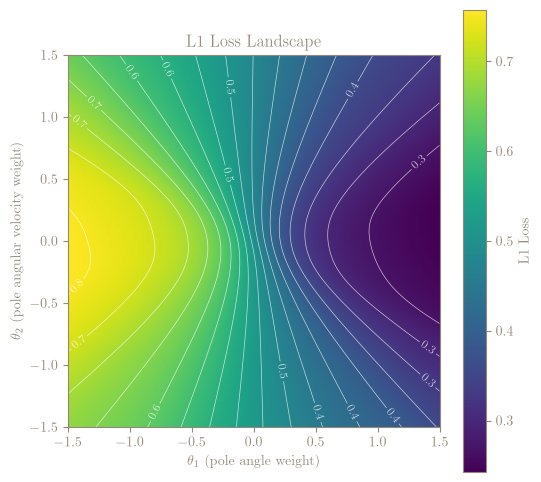

In [18]:
fig = plt.figure(0, (6, 6)); ax = fig.add_subplot(111)
extent = [theta1_vals_viz[0], theta1_vals_viz[-1], theta2_vals_viz[0], theta2_vals_viz[-1]]
im = ax.imshow(L_vals.T, origin='lower', cmap='viridis', extent=extent, aspect='equal')  # .T -> theta1 on x
T1, T2 = np.meshgrid(theta1_vals_viz, theta2_vals_viz)
cs = ax.contour(T1, T2, L_vals.T, levels=18, colors='w', linewidths=0.5, alpha=0.7)
ax.clabel(cs, inline=True, fontsize=8, fmt='%.1f', colors='w')
ax.set_xlabel(r'$\theta_1$ (pole angle weight)'); ax.set_ylabel(r'$\theta_2$ (pole angular velocity weight)')
cbar=plt.colorbar(im, label='L1 Loss'); plt.title('L1 Loss Landscape')
style_ax(ax); style_cbar(cbar)
plt.savefig(SAVE_DIR+'/supervised_landscape_1.svg')

- Ok cool, would like a "gradient field" version now when we talk about the gradient.
- Let's take a grid of points, maybe from like -1.4 to 1.4 in increments of 0.4, white dots at each point, and a white arrow pointing in the gradient direction (uphill!)

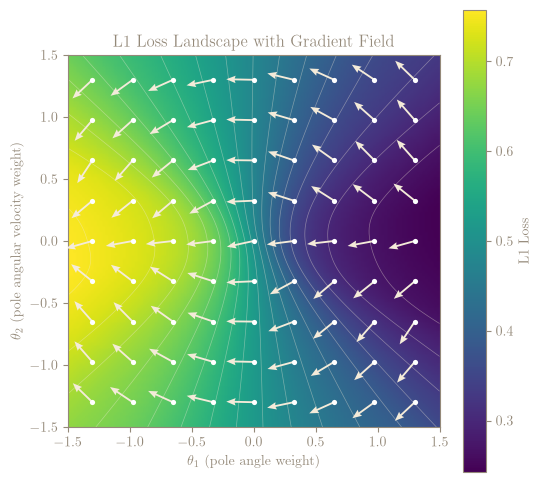

In [19]:
# --- Gradient field over the L1 loss landscape ---
GRID      = np.arange(-1.3, 1.3 + 1e-9, 0.325)   # -1.4, -1.0, ..., 1.4  (8 points per axis)
ARROW_LEN = 0.22          # arrow length in theta units (unit-length arrows show direction only)
SCALE_BY_MAG = False      # True -> arrow length proportional to gradient magnitude

G1, G2 = np.meshgrid(GRID, GRID)
U = np.zeros_like(G1); V = np.zeros_like(G2)

agent = Pi()
for i in range(G1.shape[0]):
    for j in range(G1.shape[1]):
        with torch.no_grad():
            agent.theta[:] = torch.tensor([G1[i, j], G2[i, j]])
        agent.zero_grad()
        l1_loss(agent(X), y).backward()          # dL/dtheta at this point
        U[i, j], V[i, j] = agent.theta.grad.numpy()

mag = np.hypot(U, V)
if SCALE_BY_MAG:
    Un, Vn = U / mag.max(), V / mag.max()        # longest arrow = ARROW_LEN
else:
    Un, Vn = U / mag, V / mag                    # all arrows length ARROW_LEN

fig = plt.figure(0, (6, 6)); ax = fig.add_subplot(111)
extent = [theta1_vals_viz[0], theta1_vals_viz[-1], theta2_vals_viz[0], theta2_vals_viz[-1]]
im = ax.imshow(L_vals.T, origin='lower', cmap='viridis', extent=extent, aspect='equal')
T1, T2 = np.meshgrid(theta1_vals_viz, theta2_vals_viz)
ax.contour(T1, T2, L_vals.T, levels=18, colors=FRESH_TAN, linewidths=0.5, alpha=0.4)

ax.scatter(G1, G2, s=14, color='w', zorder=5, linewidths=0)                     # white dots
ax.quiver(G1, G2, ARROW_LEN*Un, ARROW_LEN*Vn,                                   # white arrows, uphill
          angles='xy', scale_units='xy', scale=1, color=FRESH_TAN,
          width=0.005, headwidth=4, headlength=5, headaxislength=4.5, zorder=4)

ax.set_xlabel(r'$\theta_1$ (pole angle weight)'); ax.set_ylabel(r'$\theta_2$ (pole angular velocity weight)')
cbar = plt.colorbar(im, label='L1 Loss'); plt.title('L1 Loss Landscape with Gradient Field')
style_ax(ax); style_cbar(cbar)
plt.savefig(SAVE_DIR + '/supervised_landscape_gradient_1.svg')

In [20]:
GRID

array([-1.30000000e+00, -9.75000000e-01, -6.50000000e-01, -3.25000000e-01,
       -2.22044605e-16,  3.25000000e-01,  6.50000000e-01,  9.75000000e-01,
        1.30000000e+00])

In [21]:
# SEP = 4            # minimum spaces between columns
# N_STEPS = None     # e.g. 10 to only show the first 10 rows; None for all 66
# THETA = [0.65, -1.3] # theta at which to evaluate

# with torch.no_grad():
#     agent.theta[:] = torch.tensor(THETA)
#     yhat = agent(X).squeeze()

# s  = torch.sign(y - yhat)          # sign(y - yhat)
# d  = yhat * (1 - yhat)             # yhat(1 - yhat)
# g1 = s * d * X[:, 0]               # sign(y-yhat) * yhat(1-yhat) * x1
# g2 = s * d * X[:, 1]               # sign(y-yhat) * yhat(1-yhat) * x2

# n = len(X) if N_STEPS is None else N_STEPS
# rows = [[f'{t+1}', f'{X[t,0]:.2f}', f'{X[t,1]:.2f}', f'{int(y[t])}', f'{yhat[t]:.2f}',
#          f'{int(s[t])}', f'{d[t]:.2f}', f'{g1[t]:.2f}', f'{g2[t]:.2f}'] for t in range(n)]

# widths = [max(len(r[c]) for r in rows) for c in range(len(rows[0]))]
# gap = ' ' * SEP
# table = '\n'.join(gap.join(cell.rjust(w) for cell, w in zip(r, widths)) for r in rows)
# print(table)

# print(f'\nmean of last two columns = [{g1[:n].mean():.4f}, {g2[:n].mean():.4f}]')
# print(f'gradient dL/dtheta       = [{-g1[:n].mean():.4f}, {-g2[:n].mean():.4f}]')

In [22]:
# SEP = 4            # minimum spaces between columns
# N_STEPS = None     # e.g. 10 to only show the first 10 rows; None for all 66
# THETA = [0.65, -1.3] # theta at which to evaluate

# with torch.no_grad():
#     agent.theta[:] = torch.tensor(THETA)
#     yhat = agent(X).squeeze()

# s  = torch.sign(y - yhat)
# d  = yhat * (1 - yhat)
# g1 = s * d * X[:, 0]               # sign(y-yhat) * yhat(1-yhat) * x1
# g2 = s * d * X[:, 1]               # sign(y-yhat) * yhat(1-yhat) * x2

# n = len(X) if N_STEPS is None else N_STEPS
# rows = [[f'{t+1}', f'{X[t,0]:.2f}', f'{X[t,1]:.2f}', f'{int(y[t])}', f'{yhat[t]:.2f}',
#          f'{g1[t]:.2f}', f'{g2[t]:.2f}'] for t in range(n)]

# widths = [max(len(r[c]) for r in rows) for c in range(len(rows[0]))]
# gap = ' ' * SEP
# table = '\n'.join(gap.join(cell.rjust(w) for cell, w in zip(r, widths)) for r in rows)
# print(table)

# print(f'\nmean of last two columns = [{g1[:n].mean():.4f}, {g2[:n].mean():.4f}]')
# print(f'gradient dL/dtheta       = [{-g1[:n].mean():.4f}, {-g2[:n].mean():.4f}]')

In [23]:
SEP = 3              # minimum spaces between columns
N_STEPS = None       # e.g. 10 to only show the first 10 rows; None for all 66
# THETA = [0.65, -1.3] # theta at which to evaluate
THETA = [0.33, -0.33] # theta at which to evaluate

with torch.no_grad():
    agent.theta[:] = torch.tensor(THETA)
    z    = X @ agent.theta            # logit, before the sigmoid
    yhat = torch.sigmoid(z)           # same as agent(X)

s  = torch.sign(y - yhat)
d  = yhat * (1 - yhat)
g1 = s * d * X[:, 0]               # sign(y-yhat) * yhat(1-yhat) * x1
g2 = s * d * X[:, 1]               # sign(y-yhat) * yhat(1-yhat) * x2

n = len(X) if N_STEPS is None else N_STEPS
rows = [[f'{t+1}', f'{X[t,0]:.2f}', f'{X[t,1]:.2f}', f'{THETA[0]:.2f}', f'{THETA[1]:.2f}',
         f'{int(y[t])}', f'{yhat[t]:.2f}', f'{z[t]:.2f}', f'{-g1[t]:.2f}', f'{-g2[t]:.2f}'] for t in range(n)]

widths = [max(len(r[c]) for r in rows) for c in range(len(rows[0]))]
gap = ' ' * SEP
table = '\n'.join(gap.join(cell.rjust(w) for cell, w in zip(r, widths)) for r in rows)
print(table)

print(f'\nmean of last two columns = [{g1[:n].mean():.4f}, {g2[:n].mean():.4f}]')
print(f'gradient dL/dtheta       = [{-g1[:n].mean():.4f}, {-g2[:n].mean():.4f}]')

 1    1.69   -0.16   0.33   -0.33   1   0.65    0.61   -0.39    0.04
 2    1.66   -1.78   0.33   -0.33   1   0.76    1.14   -0.30    0.33
 3    1.30   -3.41   0.33   -0.33   1   0.83    1.55   -0.19    0.49
 4    0.62   -5.04   0.33   -0.33   1   0.87    1.87   -0.07    0.58
 5   -0.39   -6.70   0.33   -0.33   1   0.89    2.08    0.04    0.66
 6   -1.73   -8.39   0.33   -0.33   0   0.90    2.20   -0.16   -0.75
 7   -3.41   -6.77   0.33   -0.33   0   0.75    1.11   -0.64   -1.26
 8   -4.76   -5.20   0.33   -0.33   0   0.54    0.14   -1.18   -1.29
 9   -5.80   -3.68   0.33   -0.33   0   0.33   -0.70   -1.29   -0.82
10   -6.54   -2.19   0.33   -0.33   0   0.19   -1.43   -1.02   -0.34
11   -6.98   -0.74   0.33   -0.33   0   0.11   -2.06   -0.70   -0.07
12   -7.12    0.71   0.33   -0.33   0   0.07   -2.58   -0.46    0.05
13   -6.98    2.15   0.33   -0.33   0   0.05   -3.01   -0.31    0.10
14   -6.55    3.59   0.33   -0.33   0   0.03   -3.35   -0.22    0.12
15   -5.84    5.05   0.33   -0.33 

In [24]:
# with torch.no_grad():
#     yhat = agent(X)
#     dL_dyhat  = torch.sign(yhat - y)          # derivative of |y - yhat| w.r.t. yhat
#     dyhat_dz  = yhat * (1 - yhat)             # derivative of sigmoid w.r.t. its input z = x @ theta
#     dz_dtheta = X                             # (66, 2)
#     grad_manual = (dL_dyhat * dyhat_dz) @ dz_dtheta /len(X)  # average over examples happens in the matmul

# grad_manual, grad, torch.allclose(grad_manual, grad)

In [25]:
def plot_loss_landscape(ax, L_vals, theta1_vals, theta2_vals, levels=18, labels=True): #Helper
    extent = [theta1_vals[0], theta1_vals[-1], theta2_vals[0], theta2_vals[-1]]
    im = ax.imshow(L_vals.T, origin='lower', cmap='viridis', extent=extent, aspect='equal')  # .T -> theta1 on x
    T1, T2 = np.meshgrid(theta1_vals, theta2_vals)
    cs = ax.contour(T1, T2, L_vals.T, levels=levels, colors='w', linewidths=0.5, alpha=0.7)
    if labels: ax.clabel(cs, inline=True, fontsize=8.5, fmt='%.1f', colors='w')
    ax.set_xlabel(r'$\theta_1$ (pole angle parameter)'); ax.set_ylabel(r'$\theta_2$ (pole angular velocity parameter)')
    style_ax(ax); #style_cbar(
    return im

In [26]:
theta_0 = torch.tensor([-0.7, -0.1])

In [27]:
lr = 0.01     
steps = 1000

agent = Pi()
with torch.no_grad():
    agent.theta[:] = theta_0
opt = optim.SGD(agent.parameters(), lr=lr) 

traj, losses = [agent.theta.detach().clone()], []
for step in range(steps):
    loss = l1_loss(agent(X), y)
    opt.zero_grad(); loss.backward(); opt.step()
    traj.append(agent.theta.detach().clone()); losses.append(loss.item())
    if step % 100 == 0 or step == steps - 1:
        acc = ((agent(X) >= 0.5).int() == y).float().mean().item()
        print(f'step {step:5d}  loss {loss.item():7.3f}  acc {acc:.3f}  theta = ({agent.theta[0]:+.3f}, {agent.theta[1]:+.3f})')
    
traj = torch.stack(traj).numpy()   

step     0  loss   0.711  acc 0.197  theta = (-0.699, -0.100)
step   100  loss   0.698  acc 0.197  theta = (-0.585, -0.118)
step   200  loss   0.671  acc 0.227  theta = (-0.425, -0.149)
step   300  loss   0.581  acc 0.348  theta = (-0.133, -0.189)
step   400  loss   0.362  acc 0.742  theta = (+0.318, -0.095)
step   500  loss   0.311  acc 0.803  theta = (+0.531, -0.042)
step   600  loss   0.294  acc 0.773  theta = (+0.659, -0.020)
step   700  loss   0.284  acc 0.773  theta = (+0.756, -0.006)
step   800  loss   0.277  acc 0.773  theta = (+0.838, +0.005)
step   900  loss   0.272  acc 0.773  theta = (+0.909, +0.015)
step   999  loss   0.268  acc 0.788  theta = (+0.973, +0.024)


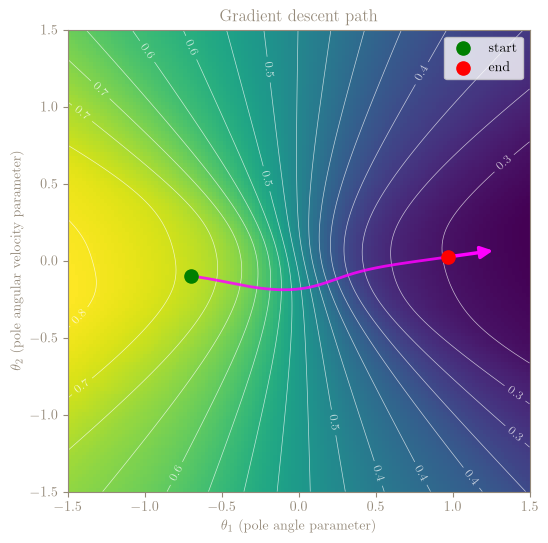

In [28]:
fig = plt.figure(0, (6, 6)); ax = fig.add_subplot(111)
im = plot_loss_landscape(ax, L_vals, theta1_vals_viz, theta2_vals_viz)
ax.plot(traj[:, 0], traj[:, 1], color='magenta', lw=2, alpha=0.85, zorder=4)
u = -agent.theta.grad.numpy()*5
ax.annotate('', xy=traj[-1] + u, xytext=traj[-1], arrowprops=dict(arrowstyle='-|>', color='magenta', lw=2.5, mutation_scale=18), zorder=6)
ax.scatter(*traj[0],  s=90, color='g', zorder=10, label='start')
ax.scatter(*traj[-1], s=90, color='r', zorder=10, label='end')
ax.legend(); plt.title('Gradient descent path')
plt.savefig(SAVE_DIR + '/learning_process_1.svg')

- Ok Now I'd like a version of this training trajectory plot above, with N checkpoints along the way.
- Let's start with N=7 + start and end
- For each point I want to render a white circle on the path
- Then below in a separate cell, I want to render the overead 2D orange/blue statespace heatmap with the training trajectory arrows and line on top. Let's do this in a 3x3 subplot grid. 

In [29]:
N_CKPT = 6   # interior checkpoints; +2 for start and end
ckpt_idx = np.round(np.linspace(0, len(traj)-1, N_CKPT+2)).astype(int)   # evenly spaced in step count
ckpt_idx

array([   0,  143,  286,  429,  571,  714,  857, 1000])

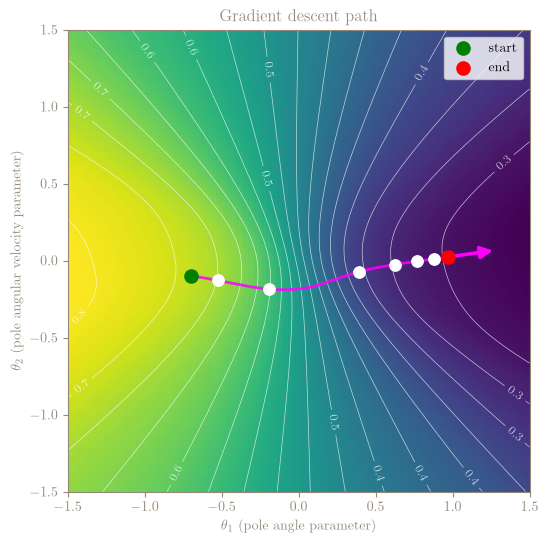

In [30]:
fig = plt.figure(0, (6, 6)); ax = fig.add_subplot(111)
im = plot_loss_landscape(ax, L_vals, theta1_vals_viz, theta2_vals_viz)
ax.plot(traj[:, 0], traj[:, 1], color='magenta', lw=2, alpha=0.85, zorder=4)
u = -agent.theta.grad.numpy()*5
ax.annotate('', xy=traj[-1] + u, xytext=traj[-1], arrowprops=dict(arrowstyle='-|>', color='magenta', lw=2.5, mutation_scale=18), zorder=6)

ax.scatter(traj[ckpt_idx, 0], traj[ckpt_idx, 1], s=70, facecolor='w', edgecolor='w', lw=0.8, zorder=8)   # white checkpoint circles
ax.scatter(*traj[0],  s=90, color='g', zorder=10, label='start')
ax.scatter(*traj[-1], s=90, color='r', zorder=10, label='end')
ax.legend(); plt.title('Gradient descent path')
style_ax(ax)
plt.savefig(SAVE_DIR + '/learning_process_checkpoints_1.svg')

In [31]:
def compute_yhat_grid(agent, n=128):   # Helper: network output over a grid of states
    A, V = np.meshgrid(np.linspace(*ANG_LIM, n), np.linspace(*VEL_LIM, n))
    with torch.no_grad():
        grid = torch.tensor(np.stack([A.ravel(), V.ravel()], axis=1), dtype=torch.float32)
        yhat_grid = agent(grid).reshape(A.shape).numpy()
    return A, V, yhat_grid

def plot_yhat_grid(ax, A, V, yhat_grid, alpha=0.5):   # Helper: shaded regions + decision boundary
    im = ax.imshow(yhat_grid, origin='lower', vmin=0, vmax=1, cmap=cmap,
                   extent=[*ANG_LIM, *VEL_LIM], aspect='auto', alpha=alpha)
    ax.contour(A, V, yhat_grid, levels=[0.5], colors='w', linestyles='--', linewidths=1.5)
    return im

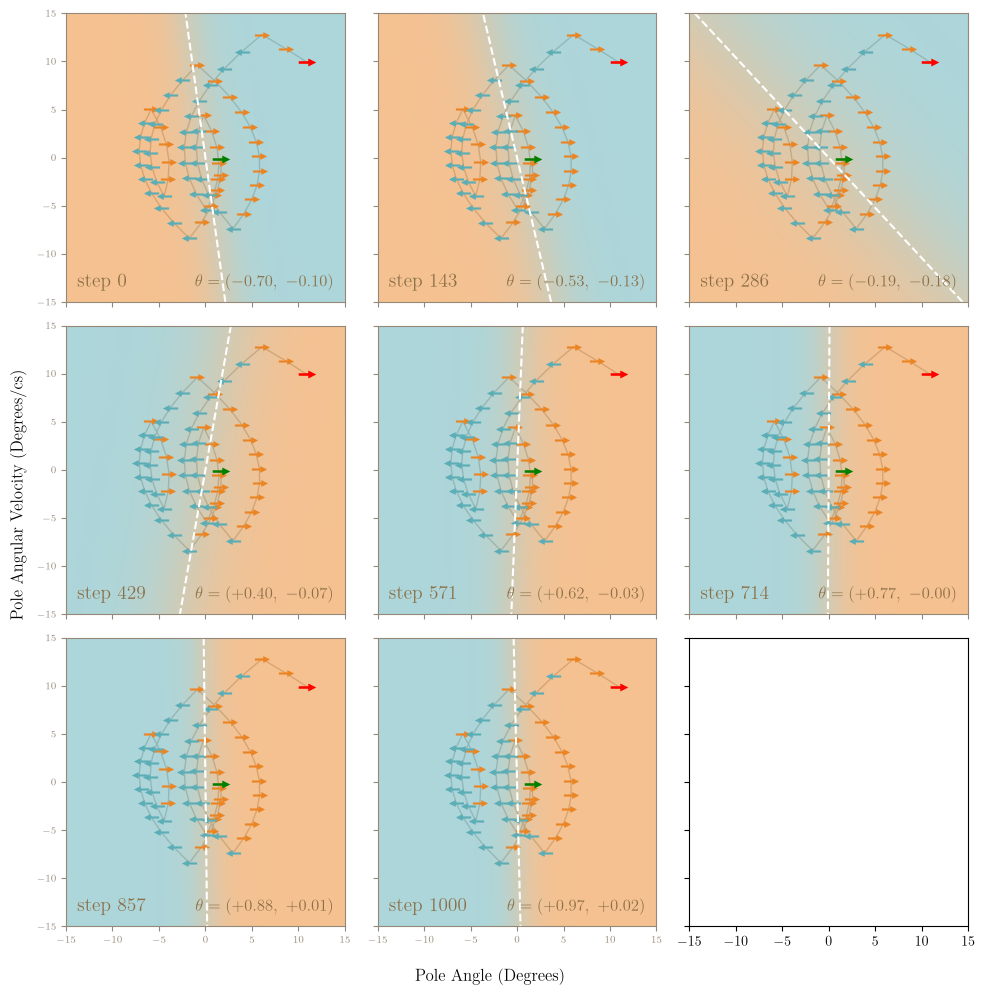

In [32]:
ckpt_agent = Pi()   # scratch model so we don't disturb the trained `agent`
fig, axs = plt.subplots(3, 3, figsize=(10, 10), sharex=True, sharey=True)

for ax, k in zip(axs.ravel(), ckpt_idx):
    with torch.no_grad():
        ckpt_agent.theta[:] = torch.tensor(traj[k])
    A_k, V_k, yhat_k = compute_yhat_grid(ckpt_agent)
    plot_yhat_grid(ax, A_k, V_k, yhat_k, alpha=0.5)

    m = (y == 1)   # the human game the policy is fit to
    ax.plot(X[:,0], X[:,1], color=CHILL_BROWN, lw=1, alpha=0.5, zorder=-10)
    ax.scatter(X[m, 0],  X[m, 1],  marker=RIGHT_ARROW, s=120, color=ORANGE,  linewidths=0)
    ax.scatter(X[~m, 0], X[~m, 1], marker=LEFT_ARROW,  s=120, color=LT_BLUE, linewidths=0)
    ax.scatter(X[0, 0],  X[0, 1],  marker=RIGHT_ARROW if y[0]==1  else LEFT_ARROW, s=160, color='g', linewidths=0)
    ax.scatter(X[-1, 0], X[-1, 1], marker=RIGHT_ARROW if y[-1]==1 else LEFT_ARROW, s=160, color='r', linewidths=0)

    # Labels drawn on the plot itself
    ax.text(0.04, 0.04, f'step {k}', transform=ax.transAxes,
            ha='left', va='bottom', fontsize=14, fontweight='bold',
            family='sans-serif', color='#8B6F47', zorder=20)
    ax.text(0.96, 0.04, rf'$\theta = ({traj[k,0]:+.2f},\ {traj[k,1]:+.2f})$', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=12, color='#8B6F47', zorder=20)

    ax.set_xlim(*ANG_LIM); ax.set_ylim(*VEL_LIM)
    style_ax(ax); ax.tick_params(labelsize=7)

fig.supxlabel('Pole Angle (Degrees)'); fig.supylabel('Pole Angular Velocity (Degrees/cs)')
plt.tight_layout()
plt.savefig(SAVE_DIR + '/learning_process_state_space_grid_1.svg')

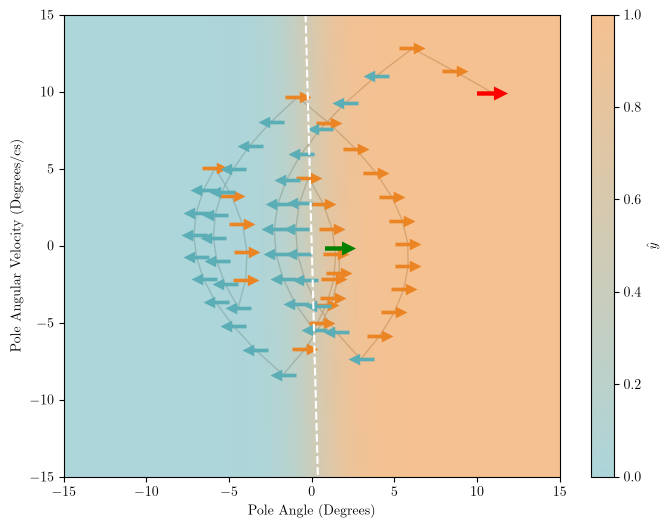

In [33]:
fig=plt.figure(0, (8,6))
ax=fig.add_subplot(111)

A, V, yhat_grid=compute_yhat_grid(agent)
im=plot_yhat_grid(ax, A, V, yhat_grid, alpha=0.5)
plt.colorbar(im, label='$\hat{y}$')

m = (y == 1)
plt.plot(X[:,0], X[:,1], color=CHILL_BROWN, lw=1, alpha=0.5, zorder=-10)
ax.scatter(X[m, 0],  X[m, 1],  marker=RIGHT_ARROW, s=350, color=ORANGE, alpha=1.0, linewidths=0)
ax.scatter(X[~m, 0], X[~m, 1], marker=LEFT_ARROW,  s=350, color=LT_BLUE,   alpha=1.0, linewidths=0)
ax.scatter(X[0, 0],  X[0, 1],  marker= RIGHT_ARROW if y[0]==1 else LEFT_ARROW, s=500, color='g', alpha=1.0, linewidths=0) #First step green
ax.scatter(X[-1, 0],  X[-1, 1],  marker= RIGHT_ARROW if y[-1]==1 else LEFT_ARROW, s=500, color='r', alpha=1.0, linewidths=0) #Last step red
plt.xlabel('Pole Angle (Degrees)'); plt.ylabel('Pole Angular Velocity (Degrees/cs)')
plt.savefig(SAVE_DIR + '/supervised_state_space_result_1.svg')

In [34]:
def to_features(state):
    """Gymnasium state [x, x_dot, angle, ang_vel] (radians) -> the 2 features our agent trained on."""
    f = torch.tensor(state[2:4], dtype=torch.float32) * 180/np.pi   # angle, angular velocity in degrees
    f[1] = f[1] / VEL_SCALE
    return f

def run_episode(agent, seed, max_steps=500):   # CartPole-v1 truncates at 500 steps
    env = gym.make("CartPole-v1")
    state, _ = env.reset(seed=seed)
    X_ep, y_ep = [], []
    for t in range(max_steps):
        with torch.no_grad():
            features = to_features(state)
            action = int(agent(features) >= 0.5)   # yhat >= 0.5 -> push right
        X_ep.append(features); y_ep.append(action)
        state, reward, terminated, truncated, _ = env.step(action)
        if terminated or truncated: break
    return torch.stack(X_ep), torch.tensor(y_ep)

def plot_state_space(ax, X_ep, y_ep, s=120):   # Helper: same picture as our human data plot
    m = (y_ep == 1)
    ax.plot(X_ep[:,0], X_ep[:,1], color=CHILL_BROWN, lw=1, alpha=0.5, zorder=-10)
    ax.scatter(X_ep[m, 0],  X_ep[m, 1],  marker=RIGHT_ARROW, s=s, color=ORANGE,  linewidths=0)
    ax.scatter(X_ep[~m, 0], X_ep[~m, 1], marker=LEFT_ARROW,  s=s, color=LT_BLUE, linewidths=0)
    ax.scatter(X_ep[0, 0],  X_ep[0, 1],  marker=RIGHT_ARROW if y_ep[0]==1  else LEFT_ARROW, s=s*1.3, color='g', linewidths=0)
    ax.scatter(X_ep[-1, 0], X_ep[-1, 1], marker=RIGHT_ARROW if y_ep[-1]==1 else LEFT_ARROW, s=s*1.3, color='r', linewidths=0)
    ax.set_xlim(*ANG_LIM); ax.set_ylim(*VEL_LIM)

In [35]:
X_ep, y_ep = run_episode(agent, seed=2)
print(f'Episode length: {len(y_ep)} steps')

Episode length: 35 steps


In [36]:
N_EPISODES = 2048
episodes = [run_episode(agent, seed=i) for i in tqdm(range(N_EPISODES))]
lengths = np.array([len(y_ep) for _, y_ep in episodes])
print(f'Average episode length: {lengths.mean():.1f} steps  (min {lengths.min()}, max {lengths.max()})')

100%|████████████████████████████████████████████| 2048/2048 [00:02<00:00, 862.35it/s]

Average episode length: 47.2 steps  (min 25, max 89)


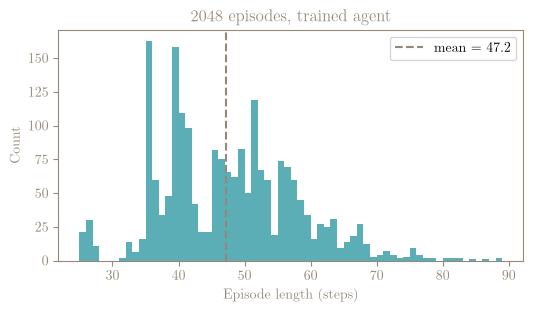

In [37]:
fig=plt.figure(0, (6, 3))
ax=fig.add_subplot(111)
plt.hist(lengths, bins=64, color=LT_BLUE)
plt.axvline(lengths.mean(), color=CHILL_BROWN, ls='--', label=f'mean = {lengths.mean():.1f}')
plt.xlabel('Episode length (steps)'); plt.ylabel('Count'); plt.legend()
plt.title(f'{N_EPISODES} episodes, trained agent')
style_ax(ax)
plt.savefig(SAVE_DIR + '/agent_1_histogram.svg')

In [38]:
ANG_LIM = (-15, 15) #Limits for the network output visualization
VEL_LIM = (-15, 15)   

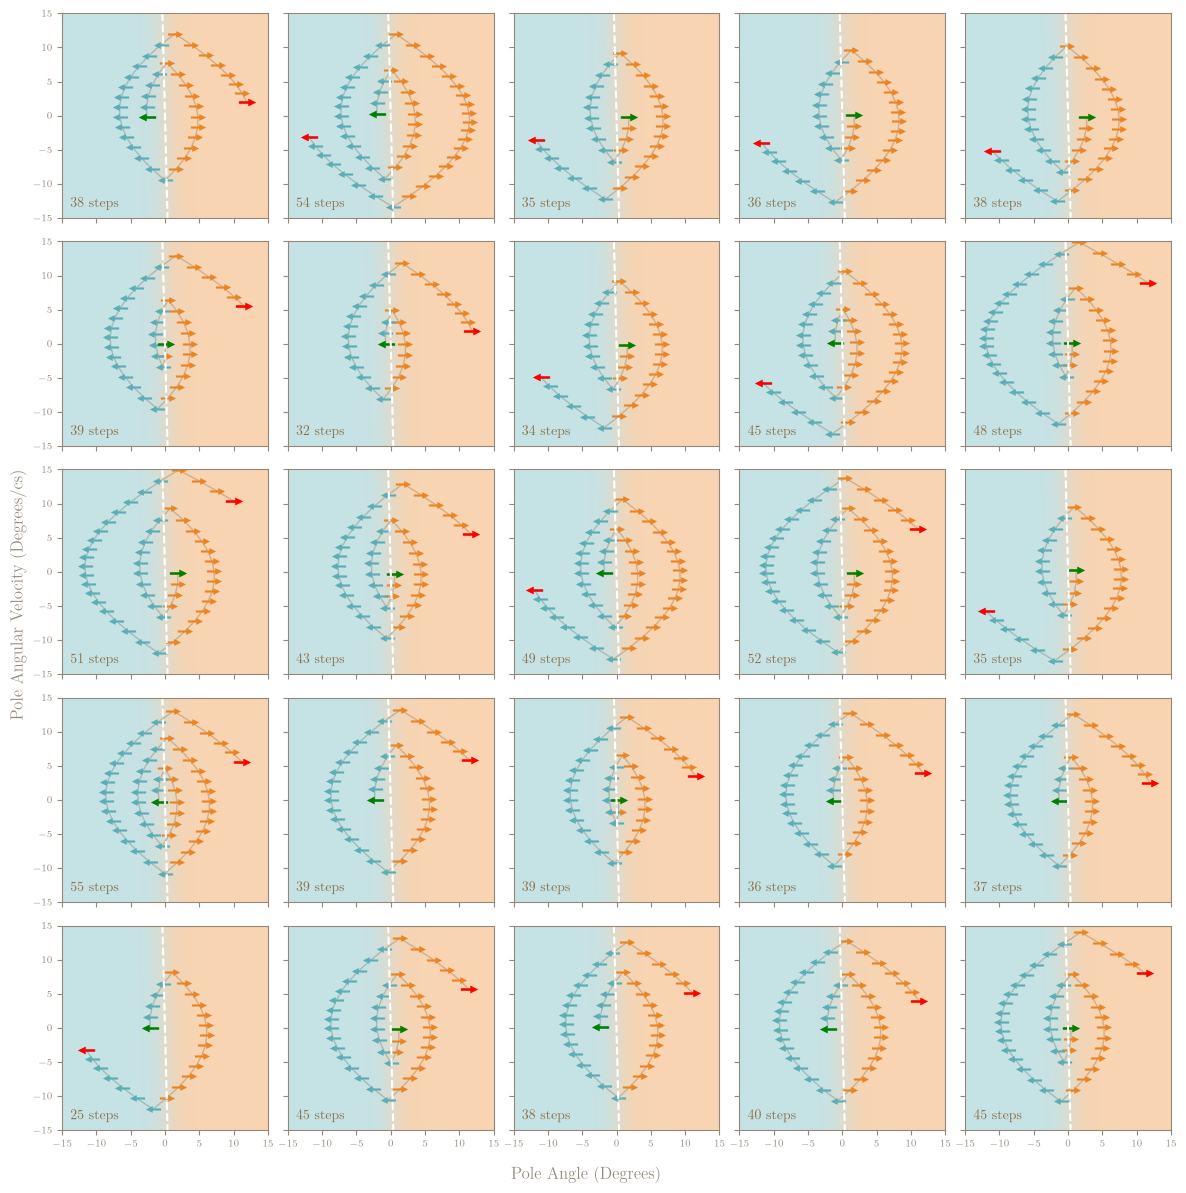

In [39]:
fig, axs = plt.subplots(5, 5, figsize=(12, 12), sharex=True, sharey=True)
for ax, (X_ep, y_ep) in zip(axs.ravel(), episodes[:25]):
    plot_yhat_grid(ax, A, V, yhat_grid, alpha=0.35)
    plot_state_space(ax, X_ep, y_ep, s=120)
    ax.text(0.04, 0.04, f'{len(y_ep)} steps', transform=ax.transAxes,
            ha='left', va='bottom', fontsize=10, fontweight='bold',
            family='sans-serif', color='#8B6F47')
    ax.tick_params(labelsize=7)
    style_ax(ax)
fig.supxlabel('Pole Angle (Degrees)', color=CHILL_BROWN); 
fig.supylabel('Pole Angular Velocity (Degrees/cs)', color=CHILL_BROWN)
plt.tight_layout()
plt.savefig(SAVE_DIR + '/agent_1_episodes.svg')

In [40]:
# Keep Stephen's artifacts around for the side-by-sides
L_Stephen, traj_Stephen, lengths_Stephen, X_Stephen, y_Stephen = L_vals, traj, lengths, X, y
agent_Stephen = Pi()
with torch.no_grad(): agent_Stephen.theta[:] = torch.tensor(traj_Stephen[-1])

### Cart pole champion!

In [41]:
with open(DATA / "champion_cartpole_game.json") as f: 
    data = json.load(f)

VEL_SCALE = 10   # divide velocities by 10 -> feature scales comparable, ~isotropic parameter space
obs = torch.tensor(data["episodes"][0]["observations"]) 
X = obs[:, 2:4] * 180/np.pi # Here we'll just use pole angle and pole angular velocity, and use degrees
X[:,1] = X[:,1] / VEL_SCALE # Scale pole angular velocity
y = torch.tensor(data['episodes'][0]['actions'])

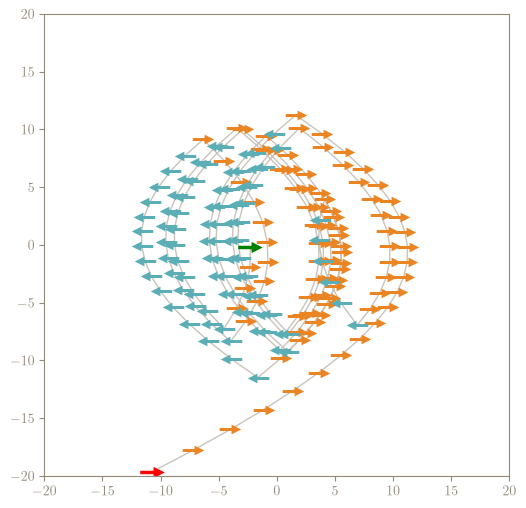

In [42]:
ANG_LIM = (-20, 20) 
VEL_LIM = (-20, 20)   

fig = plt.figure(0, (6,6)); ax = fig.add_subplot(111)
plot_state_space(ax, X, y, s=240)
style_ax(ax)

plt.savefig(SAVE_DIR+'/state_space_champion.svg')

- Ok cool yeah i definitely want to show some time series action here as we introduce the campion play!

In [43]:
X.shape

torch.Size([195, 2])

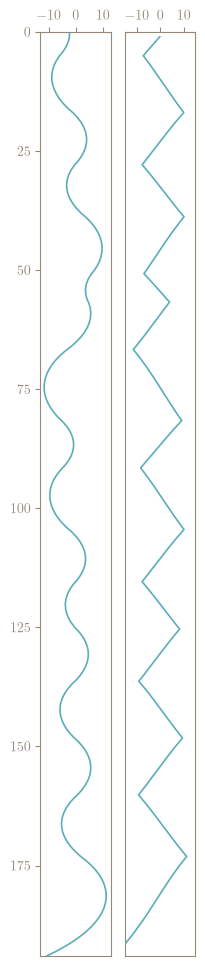

In [44]:
lw=1.2

fig=plt.figure(0, (2, 12))
ax=fig.add_subplot(1,2,1)
ax.plot(X[:,0], range(len(X)), c=LT_BLUE, lw=lw); #plt.grid(1)
plt.xlim([-13,13]);
plt.ylim([len(X)-1, 0])
style_ax(ax)
ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

ax=fig.add_subplot(1,2,2)
ax.plot(X[:,1], range(len(X)), c=LT_BLUE, lw=lw); #plt.grid(1)
plt.xlim([-15,15]);
plt.ylim([len(X)-1, -1])
style_ax(ax)
ax.tick_params(left=False, labelleft=False)
# plt.grid(1)
ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

plt.savefig(SAVE_DIR+'/time_series_champion_1.svg')

In [45]:
theta1_vals_viz = np.linspace(-1.5, 1.5, 128)
theta2_vals_viz = np.linspace(-1.5, 1.5, 128)   # span matches theta1 -> square extent

agent = Pi()
L_Champion = np.zeros((len(theta1_vals_viz), len(theta2_vals_viz)))

with torch.no_grad():
    for i, t1v in enumerate(tqdm(theta1_vals_viz)):
        for j, t2v in enumerate(theta2_vals_viz):
            agent.theta[:] = torch.tensor([t1v, t2v])     # place the model at this theta
            L_Champion[i, j] = l1_loss(agent(X), y)         # same loss, same data as training

100%|██████████████████████████████████████████████| 128/128 [00:00<00:00, 644.22it/s]


In [46]:
lr = 0.01     
steps = 1000

agent_Champion = Pi()
with torch.no_grad():
    agent_Champion.theta[:] = theta_0
opt = optim.SGD(agent_Champion.parameters(), lr=lr)

traj_Champion, losses_Champion = [agent_Champion.theta.detach().clone()], []
for step in range(steps):
    loss = l1_loss(agent_Champion(X), y)
    opt.zero_grad(); loss.backward(); opt.step()
    traj_Champion.append(agent_Champion.theta.detach().clone()); losses_Champion.append(loss.item())
    if step % 100 == 0 or step == steps - 1:
        acc = ((agent_Champion(X) >= 0.5).int() == y).float().mean().item()
        print(f'step {step:5d}  loss {loss.item():7.3f}  acc {acc:.3f}  theta = ({agent_Champion.theta[0]:+.3f}, {agent_Champion.theta[1]:+.3f})')

traj_Champion = torch.stack(traj_Champion).numpy()

step     0  loss   0.794  acc 0.159  theta = (-0.699, -0.100)
step   100  loss   0.781  acc 0.159  theta = (-0.586, -0.109)
step   200  loss   0.741  acc 0.195  theta = (-0.394, -0.152)
step   300  loss   0.377  acc 0.672  theta = (+0.174, -0.199)
step   400  loss   0.242  acc 0.805  theta = (+0.491, -0.064)
step   500  loss   0.215  acc 0.821  theta = (+0.633, +0.013)
step   600  loss   0.204  acc 0.821  theta = (+0.729, +0.053)
step   700  loss   0.198  acc 0.826  theta = (+0.803, +0.077)
step   800  loss   0.194  acc 0.836  theta = (+0.864, +0.093)
step   900  loss   0.191  acc 0.836  theta = (+0.916, +0.105)
step   999  loss   0.189  acc 0.836  theta = (+0.961, +0.115)


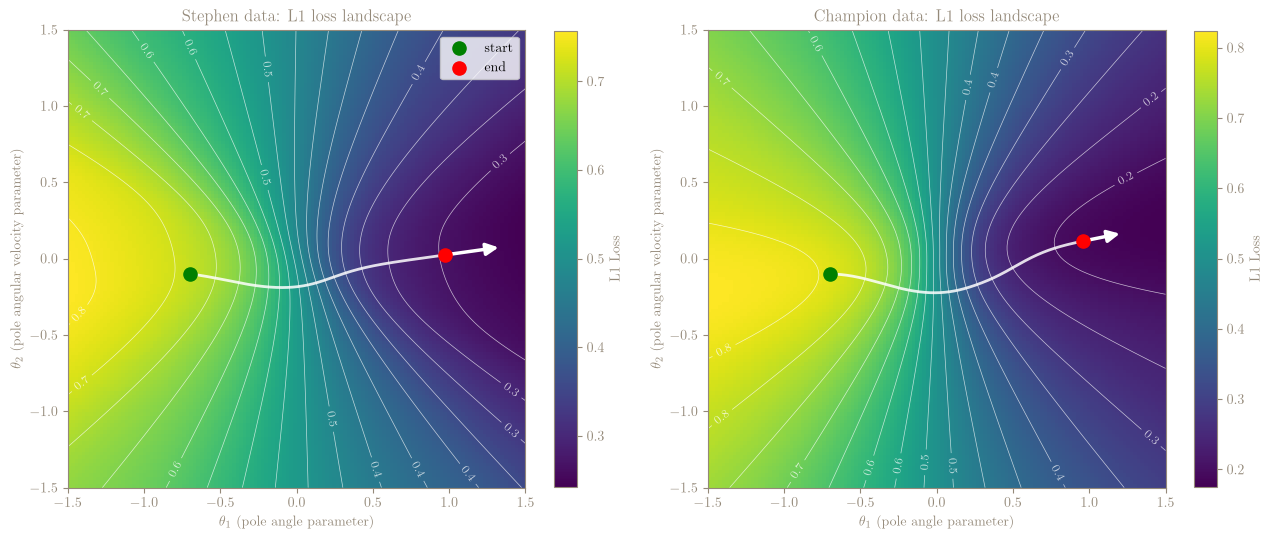

In [47]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 6))
for ax, L, tr, ag, Xd, yd, name in [(axL, L_Stephen,  traj_Stephen,  agent_Stephen,  X_Stephen, y_Stephen, 'Stephen'),
                                    (axR, L_Champion, traj_Champion, agent_Champion, X,         y,         'Champion')]:
    im = plot_loss_landscape(ax, L, theta1_vals_viz, theta2_vals_viz)
    ax.plot(tr[:, 0], tr[:, 1], color='w', lw=2, alpha=0.85, zorder=4)

    ag.zero_grad(); l1_loss(ag(Xd), yd).backward()   # gradient at the final theta
    u = -ag.theta.grad.numpy() *6               # scale to fit on plot
    ax.annotate('', xy=tr[-1] + u, xytext=tr[-1], arrowprops=dict(arrowstyle='-|>', color='w', lw=2.5, mutation_scale=18), zorder=6)

    ax.scatter(*tr[0],  s=90, color='g', zorder=10, label='start')
    ax.scatter(*tr[-1], s=90, color='r', zorder=10, label='end')
    ax.set_title(f'{name} data: L1 loss landscape'); 
    cbar=fig.colorbar(im, ax=ax, label='L1 Loss', shrink=0.8)
    style_ax(ax)
    style_cbar(cbar)
axL.legend(); plt.tight_layout()
plt.savefig(SAVE_DIR+'/training_compare.svg')

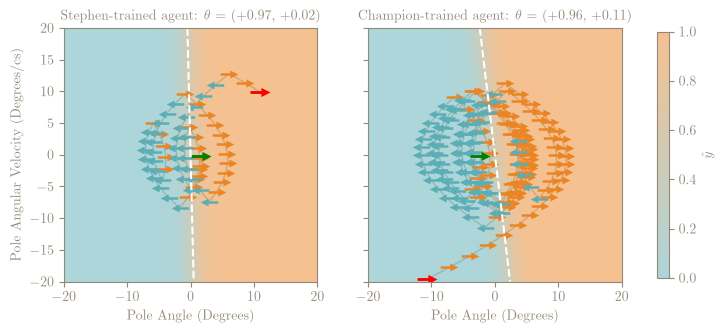

In [48]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
for ax, ag, name in [(axL, agent_Stephen, 'Stephen'), (axR, agent_Champion, 'Champion')]:
    A, V, yhat_grid = compute_yhat_grid(ag)
    im = plot_yhat_grid(ax, A, V, yhat_grid, alpha=0.5)
    ax.set_xlim(*ANG_LIM); ax.set_ylim(*VEL_LIM)
    ax.set_title(f'{name}-trained agent: $\\theta$ = ({ag.theta[0]:+.2f}, {ag.theta[1]:+.2f})', fontsize=10)
    ax.set_xlabel('Pole Angle (Degrees)')
    if name=='Stephen':
        plot_state_space(ax, X_Stephen, y_Stephen, s=160)
    else:        
        plot_state_space(ax, X, y, s=160)
    
    style_ax(ax)
    ax.set_box_aspect(1)
    
axL.set_ylabel('Pole Angular Velocity (Degrees/cs)')
cbar=fig.colorbar(im, ax=[axL, axR], label='$\\hat{y}$', shrink=0.8)
style_cbar(cbar)
plt.savefig(SAVE_DIR+'/state_space_compare.svg')

In [49]:
episodes_Champion = [run_episode(agent_Champion, seed=i) for i in tqdm(range(N_EPISODES))]
lengths_Champion = np.array([len(y_ep) for _, y_ep in episodes_Champion])
print(f'Average episode length: {lengths_Champion.mean():.1f} steps  (min {lengths_Champion.min()}, max {lengths_Champion.max()})')

100%|████████████████████████████████████████████| 2048/2048 [00:04<00:00, 410.36it/s]

Average episode length: 111.7 steps  (min 40, max 336)


In [50]:
ANG_LIM = (-15, 15) 
VEL_LIM = (-15, 15)   

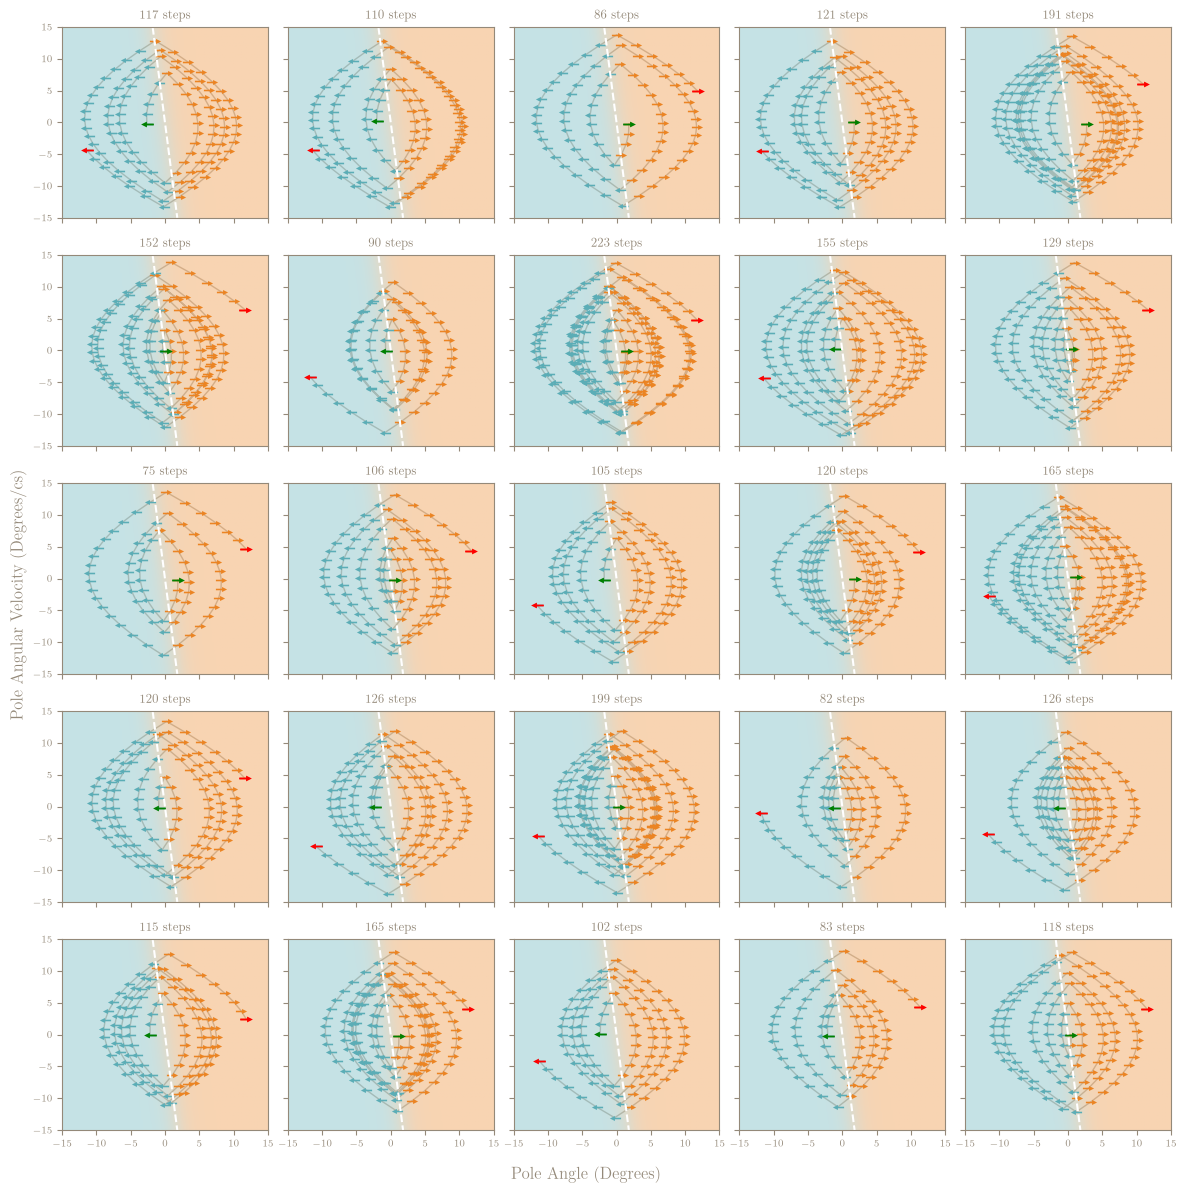

In [51]:
A, V, yhat_grid = compute_yhat_grid(agent_Champion)
fig, axs = plt.subplots(5, 5, figsize=(12, 12), sharex=True, sharey=True)
for ax, (X_ep, y_ep) in zip(axs.ravel(), episodes_Champion[:25]):
    plot_yhat_grid(ax, A, V, yhat_grid, alpha=0.35)
    plot_state_space(ax, X_ep, y_ep, s=65)
    ax.set_title(f'{len(y_ep)} steps', fontsize=9); ax.tick_params(labelsize=7)
    style_ax(ax)
fig.supxlabel('Pole Angle (Degrees)', color=CHILL_BROWN); 
fig.supylabel('Pole Angular Velocity (Degrees/cs)', color=CHILL_BROWN)
plt.tight_layout()
plt.savefig(SAVE_DIR + '/agent_champion_episodes.svg')

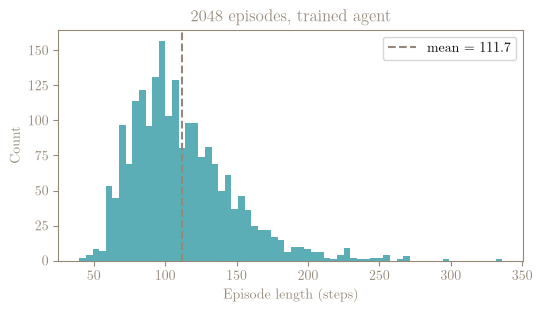

In [52]:
fig=plt.figure(0, (6, 3))
ax=fig.add_subplot(111)
plt.hist(lengths_Champion, bins=64, color=LT_BLUE)
plt.axvline(lengths_Champion.mean(), color=CHILL_BROWN, ls='--', label=f'mean = {lengths_Champion.mean():.1f}')
plt.xlabel('Episode length (steps)'); plt.ylabel('Count'); plt.legend()
plt.title(f'{N_EPISODES} episodes, trained agent')
style_ax(ax)
plt.savefig(SAVE_DIR + '/agent_champion_histogram.svg')

In [53]:
# fig, axs = plt.subplots(5, 5, figsize=(12, 12), sharex=True, sharey=True)
# for ax, (X_ep, y_ep) in zip(axs.ravel(), episodes[:25]):
#     plot_yhat_grid(ax, A, V, yhat_grid, alpha=0.35)
#     plot_state_space(ax, X_ep, y_ep, s=120)
#     ax.text(0.04, 0.04, f'{len(y_ep)} steps', transform=ax.transAxes,
#             ha='left', va='bottom', fontsize=10, fontweight='bold',
#             family='sans-serif', color='#8B6F47')
#     ax.tick_params(labelsize=7)
#     style_ax(ax)
# fig.supxlabel('Pole Angle (Degrees)', color=CHILL_BROWN); 
# fig.supylabel('Pole Angular Velocity (Degrees/cs)', color=CHILL_BROWN)
# plt.tight_layout()
# plt.savefig(SAVE_DIR + '/agent_1_episodes.svg')

## RL Time Lets GO

In [54]:
# f=np.load(DATA / 'return_landscape_deterministic_192x192_768_-1.0+1.0.npz')
f=np.load('/Users/stephen/ai_book_vol_2/chapters/02-reinforcement-learning/data/return_landscape_deterministic_256x256_1024_-1.0+1.0.npz')
R_mean=f['R_mean']; R_std=f['R_std']
theta1_vals_R=f['theta1_vals']; theta2_vals_R=f['theta1_vals']

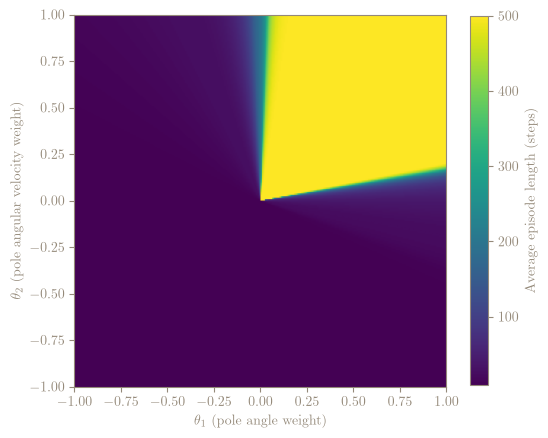

In [55]:
fig = plt.figure(0, (6, 6)); ax = fig.add_subplot(111)
extent = [theta1_vals_R[0], theta1_vals_R[-1], theta2_vals_R[0], theta2_vals_R[-1]]
im = ax.imshow(R_mean.T, origin='lower', cmap='viridis', extent=extent, aspect='equal') 
ax.set_xlabel(r'$\theta_1$ (pole angle weight)'); ax.set_ylabel(r'$\theta_2$ (pole angular velocity weight)')
cbar=plt.colorbar(im, label='Average episode length (steps)', shrink=0.8)
style_ax(ax); style_cbar(cbar)
plt.savefig(SAVE_DIR + '/average_return_landscape_1.svg')

In [56]:
theta1_vals_viz = np.linspace(-1.0, 1.0, 128)
theta2_vals_viz = np.linspace(-1.0, 1.0, 128)   # span matches theta1 -> square extent

agent = Pi()
L_vals = np.zeros((len(theta1_vals_viz), len(theta2_vals_viz)))

with torch.no_grad():
    for i, t1v in enumerate(tqdm(theta1_vals_viz)):
        for j, t2v in enumerate(theta2_vals_viz):
            agent.theta[:] = torch.tensor([t1v, t2v])     # place the model at this theta
            L_vals[i, j] = l1_loss(agent(X), y)         # same loss, same data as training

100%|██████████████████████████████████████████████| 128/128 [00:00<00:00, 626.94it/s]


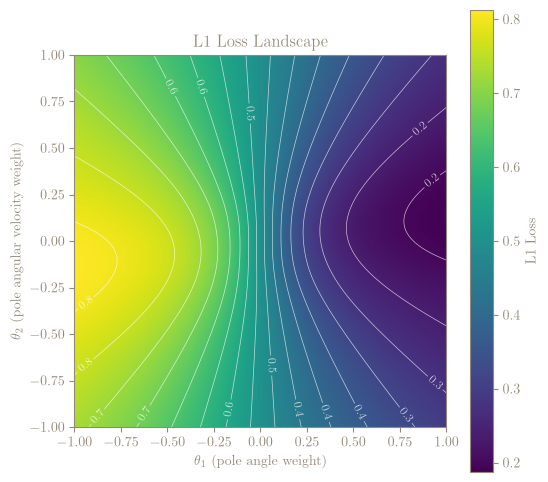

In [57]:
fig = plt.figure(0, (6, 6)); ax = fig.add_subplot(111)
extent = [theta1_vals_viz[0], theta1_vals_viz[-1], theta2_vals_viz[0], theta2_vals_viz[-1]]
im = ax.imshow(L_vals.T, origin='lower', cmap='viridis', extent=extent, aspect='equal')  # .T -> theta1 on x
T1, T2 = np.meshgrid(theta1_vals_viz, theta2_vals_viz)
cs = ax.contour(T1, T2, L_vals.T, levels=18, colors='w', linewidths=0.5, alpha=0.7)
ax.clabel(cs, inline=True, fontsize=8, fmt='%.1f', colors='w')
ax.set_xlabel(r'$\theta_1$ (pole angle weight)'); ax.set_ylabel(r'$\theta_2$ (pole angular velocity weight)')
cbar=plt.colorbar(im, label='L1 Loss'); plt.title('L1 Loss Landscape')
style_ax(ax); style_cbar(cbar)
plt.savefig(SAVE_DIR+'/supervised_landscape_3.svg')

## A tale of two agents

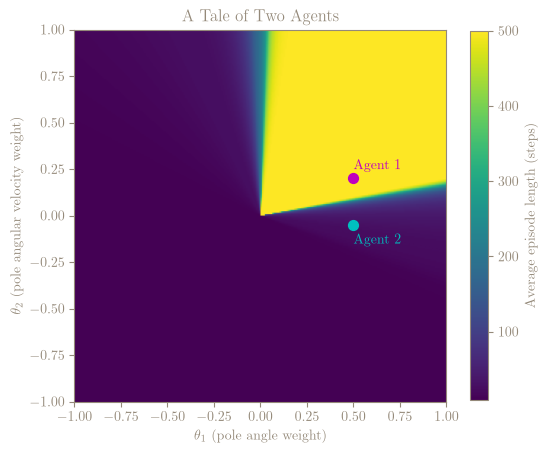

In [58]:
fig = plt.figure(0, (6, 6)); ax = fig.add_subplot(111)
extent = [theta1_vals_R[0], theta1_vals_R[-1], theta2_vals_R[0], theta2_vals_R[-1]]
im = ax.imshow(R_mean.T, origin='lower', cmap='viridis', extent=extent, aspect='equal') 
ax.set_xlabel(r'$\theta_1$ (pole angle weight)'); ax.set_ylabel(r'$\theta_2$ (pole angular velocity weight)')
cbar=plt.colorbar(im, label='Average episode length (steps)', shrink=0.8)
plt.title('A Tale of Two Agents')
plt.scatter(0.5, 0.2, c='m', s=50); plt.text(0.5, 0.25, 'Agent 1', c='m')
plt.scatter(0.5, -0.05, c='c', s=50); plt.text(0.5, -0.15, 'Agent 2', c='c')
style_ax(ax); style_cbar(cbar)
plt.savefig(SAVE_DIR+'/a_tale_of_two_agents_1.svg')

In [59]:
agent_1 = Pi()
with torch.no_grad(): agent_1.theta[:] = torch.tensor([0.5, 0.2])
episodes_A = [run_episode(agent_1, seed=i) for i in range(9)]

agent_2 = Pi()
with torch.no_grad(): agent_2.theta[:] = torch.tensor([0.5, -0.05])
episodes_B = [run_episode(agent_2, seed=i) for i in range(9)]


In [60]:
episodes_A2 = [run_episode(agent_1, seed=0) for i in range(3)] #Fixed seed
episodes_B2 = [run_episode(agent_2, seed=0) for i in range(3)] #Fixed seed

In [61]:
episodes_B2[0]

(tensor([[ -2.6300,  -0.2770],
         [ -2.6854,   1.3150],
         [ -2.4224,   2.9052],
         [ -1.8414,   4.5041],
         [ -0.9406,   6.1221],
         [  0.2838,   7.7693],
         [  1.8377,   9.4551],
         [  3.7287,   7.8364],
         [  5.2960,   6.2800],
         [  6.5520,   4.7771],
         [  7.5074,   3.3181],
         [  8.1710,   1.8931],
         [  8.5496,   0.4921],
         [  8.6481,  -0.8953],
         [  8.4690,  -2.2791],
         [  8.0132,  -3.6695],
         [  7.2793,  -5.0765],
         [  6.2640,  -6.5101],
         [  4.9620,  -7.9796],
         [  3.3660,  -9.4945],
         [  1.4671, -11.0634],
         [ -0.7455, -12.6942],
         [ -3.2844, -14.3940],
         [ -6.1632, -12.8207],
         [ -8.7273, -11.3443],
         [-10.9962,  -9.9585]]),
 tensor([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
         0, 0]))

In [62]:
# episodes_A2[0]

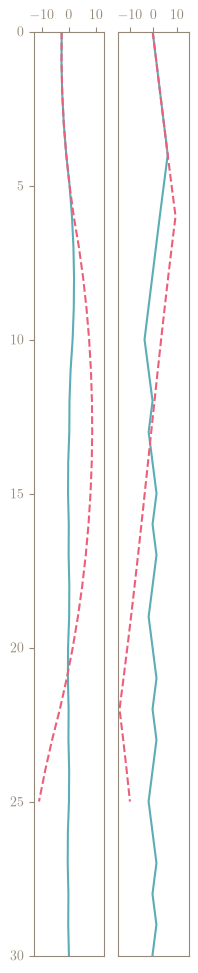

In [63]:
lw=1.5

fig=plt.figure(0, (2, 12))
ax=fig.add_subplot(1,2,1)
ax.plot(episodes_A2[0][0][:,0], range(len(episodes_A2[0][0])), c=LT_BLUE, lw=lw) #, linestyle='--'); #plt.grid(1)
ax.plot(episodes_B2[0][0][:,0], range(len(episodes_B2[0][0])), c=PINK, lw=lw, linestyle='--'); #plt.grid(1)
plt.xlim([-13,13]);
plt.ylim([30, 0])
style_ax(ax)
ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

ax=fig.add_subplot(1,2,2)
ax.plot(episodes_A2[0][0][:,1], range(len(episodes_A2[0][0])), c=LT_BLUE, lw=lw) #, linestyle='--'); #plt.grid(1)
ax.plot(episodes_B2[0][0][:,1], range(len(episodes_B2[0][0])), c=PINK, lw=lw, linestyle='--'); #plt.grid(1)
plt.xlim([-15,15]);
plt.ylim([30, 0])
style_ax(ax)
ax.tick_params(left=False, labelleft=False)
# plt.grid(1)
ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

plt.savefig(SAVE_DIR+'/two_policies_time_series.svg')

In [64]:
len(episodes_B2[0][0])

26

In [65]:
# # --- Cart-pole overlay: Agent 1 (LT_BLUE) vs Agent 2 (PINK), same seed, first N steps ---
# N_STEPS   = 26          # steps to draw (t = 0 ... N_STEPS-1)
# STYLE     = 'dashed'    # 'dashed' -> pink cartpole drawn with dashed strokes; 'alpha' -> pink cartpole drawn translucent
# PINK_ALPHA = 0.45       # only used when STYLE == 'alpha'
# SPACING   = 1.6         # vertical distance between frames (cart+pole is ~1.4 tall)
# N_COLS    = 1           # split the stack across columns, e.g. 2 -> 13 frames per column
# FIG_WIDTH = 3.0         # width of ONE column, inches
# LABEL_STEPS = True

# def run_episode_raw(agent, seed, max_steps=500):
#     """Same rollout as run_episode, but also keeps the raw gym state [x, x_dot, theta, theta_dot]."""
#     env = gym.make("CartPole-v1")
#     state, _ = env.reset(seed=seed)
#     states, actions = [], []
#     for t in range(max_steps):
#         with torch.no_grad():
#             action = int(agent(to_features(state)) >= 0.5)
#         states.append(state.copy()); actions.append(action)
#         state, reward, terminated, truncated, _ = env.step(action)
#         if terminated or truncated: break
#     return np.array(states), np.array(actions)

# def draw_cartpole_styled(ax, cart_x, pole_theta, y0=0.0, color='k', ls='-', alpha=1.0, fill_color='none', zbase=0):
#     """draw_cartpole variant with a single stroke color plus linestyle / alpha options (no track, no arrow)."""
#     cart_y = y0 + WHEEL_R*2
#     dashed = ls != '-'
#     for dx in (-CART_W*0.3, CART_W*0.3):   # wheels: solid discs, or dashed outlines in dashed mode
#         ax.add_patch(Circle((cart_x+dx, y0+WHEEL_R), WHEEL_R,
#                             fc=fill_color if dashed else color, ec=color, lw=1.5 if dashed else 0,
#                             ls=ls, alpha=alpha, zorder=zbase+3))
#     ax.add_patch(FancyBboxPatch((cart_x-CART_W/2, cart_y), CART_W, CART_H,
#                                 boxstyle="round,pad=0.02,rounding_size=0.05",
#                                 fc=fill_color, ec=color, lw=2.0, ls=ls, alpha=alpha, zorder=zbase+4))
#     px, py = cart_x, cart_y + CART_H
#     ax.plot([px, px + POLE_LEN*np.sin(pole_theta)], [py, py + POLE_LEN*np.cos(pole_theta)],
#             color=color, lw=3, ls=ls, alpha=alpha, solid_capstyle='round', dash_capstyle='round', zorder=zbase+5)
#     ax.add_patch(Circle((px, py), 0.07, color=color, alpha=alpha, zorder=zbase+6))

# # Deterministic policies + fixed seed -> these match episodes_A2[0] / episodes_B2[0] exactly
# states_A, acts_A = run_episode_raw(agent_1, seed=0)
# states_B, acts_B = run_episode_raw(agent_2, seed=0)
# assert torch.allclose(torch.stack([to_features(s) for s in states_A]), episodes_A2[0][0])
# assert torch.allclose(torch.stack([to_features(s) for s in states_B]), episodes_B2[0][0])

# n = min(N_STEPS, len(states_A), len(states_B))
# # pink_kwargs = dict(ls='--', alpha=1.0) if STYLE == 'dashed' else dict(ls='-', alpha=PINK_ALPHA)
# pink_kwargs = dict(ls=(0, (2, 1.5)), alpha=1.0) if STYLE == 'dashed' else dict(ls='-', alpha=PINK_ALPHA)

# per_col = int(np.ceil(n / N_COLS))
# x_range = X_LIM[1] - X_LIM[0]
# y_range = SPACING*(per_col-1) + 1.75 + 0.55
# fig, axs = plt.subplots(1, N_COLS, figsize=(FIG_WIDTH*N_COLS, FIG_WIDTH*y_range/x_range), squeeze=False)

# for c, ax in enumerate(axs[0]):
#     steps = range(c*per_col, min((c+1)*per_col, n))
#     for i, t in enumerate(steps):
#         y0 = -SPACING*i
#         ax.plot(X_LIM, [y0, y0], color=CHILL_BROWN, lw=1.5, zorder=1)                       # shared track
#         draw_cartpole_styled(ax, states_A[t, 0], states_A[t, 2], y0=y0, color=LT_BLUE, zbase=0)              # Agent 1 in front
#         draw_cartpole_styled(ax, states_B[t, 0], states_B[t, 2], y0=y0, color=PINK, zbase=10,  **pink_kwargs)  # Agent 2 behind
        
#         if LABEL_STEPS:
#             ax.text(X_LIM[0]-0.15, y0+0.1, f't={t}', ha='right', va='bottom', color=CHILL_BROWN, fontsize=8)
#     ax.set_xlim(*X_LIM); ax.set_ylim(-SPACING*(per_col-1)-0.55, 1.75)
#     ax.set_aspect('equal'); ax.axis('off')

# plt.tight_layout()
# plt.savefig(SAVE_DIR + f'/two_policies_cartpole_overlay_{STYLE}.svg', bbox_inches='tight', pad_inches=0.05)

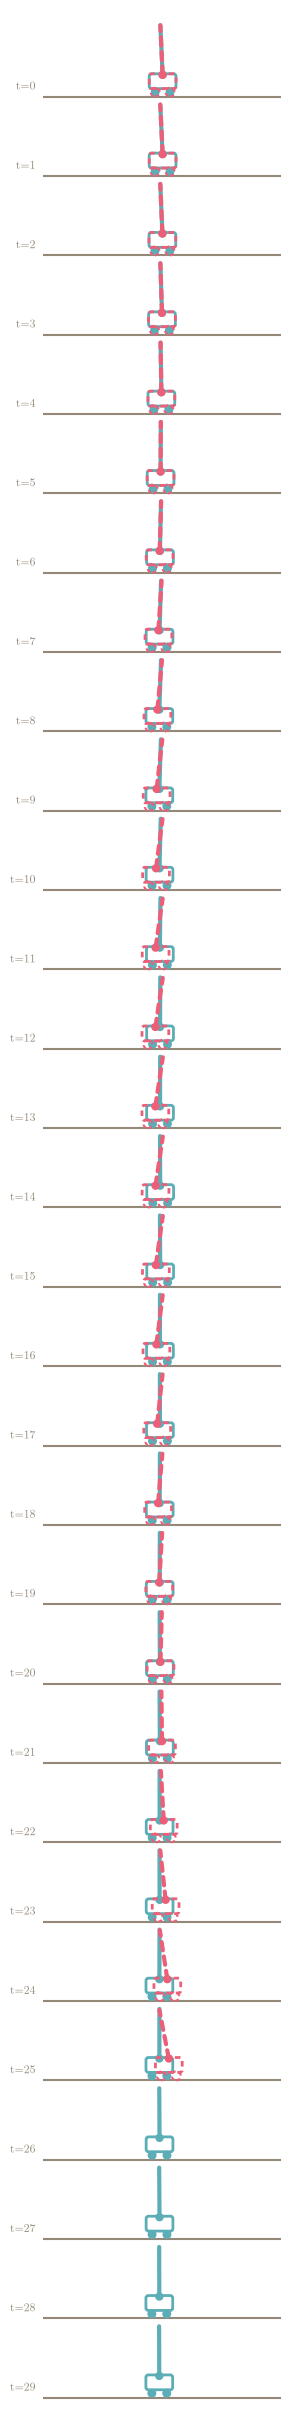

In [66]:
# --- Cart-pole overlay: Agent 1 (LT_BLUE) vs Agent 2 (PINK), same seed, first N steps ---
N_STEPS   = 30          # steps to draw (t = 0 ... N_STEPS-1)
STYLE     = 'dashed'    # 'dashed' -> pink cartpole drawn with dashed strokes; 'alpha' -> pink cartpole drawn translucent
PINK_ALPHA = 0.45       # only used when STYLE == 'alpha'
SPACING   = 1.6         # vertical distance between frames (cart+pole is ~1.4 tall)
N_COLS    = 1           # split the stack across columns, e.g. 2 -> 13 frames per column
FIG_WIDTH = 3.0         # width of ONE column, inches
LABEL_STEPS = True


def run_episode_raw(agent, seed, max_steps=500):
    """Same rollout as run_episode, but also keeps the raw gym state [x, x_dot, theta, theta_dot]."""
    env = gym.make("CartPole-v1")
    state, _ = env.reset(seed=seed)
    states, actions = [], []
    for t in range(max_steps):
        with torch.no_grad():
            action = int(agent(to_features(state)) >= 0.5)
        states.append(state.copy()); actions.append(action)
        state, reward, terminated, truncated, _ = env.step(action)
        if terminated or truncated: break
    return np.array(states), np.array(actions)

def draw_cartpole_styled(ax, cart_x, pole_theta, y0=0.0, color='k', ls='-', alpha=1.0, fill_color='none', zbase=0):
    """draw_cartpole variant with a single stroke color plus linestyle / alpha options (no track, no arrow)."""
    cart_y = y0 + WHEEL_R*2
    dashed = ls != '-'
    for dx in (-CART_W*0.3, CART_W*0.3):   # wheels: solid discs, or dashed outlines in dashed mode
        ax.add_patch(Circle((cart_x+dx, y0+WHEEL_R), WHEEL_R,
                            fc=fill_color if dashed else color, ec=color, lw=1.5 if dashed else 0,
                            ls=ls, alpha=alpha, zorder=zbase+3))
    ax.add_patch(FancyBboxPatch((cart_x-CART_W/2, cart_y), CART_W, CART_H,
                                boxstyle="round,pad=0.02,rounding_size=0.05",
                                fc=fill_color, ec=color, lw=2.0, ls=ls, alpha=alpha, zorder=zbase+4))
    px, py = cart_x, cart_y + CART_H
    ax.plot([px, px + POLE_LEN*np.sin(pole_theta)], [py, py + POLE_LEN*np.cos(pole_theta)],
            color=color, lw=3, ls=ls, alpha=alpha, solid_capstyle='round', dash_capstyle='round', zorder=zbase+5)
    ax.add_patch(Circle((px, py), 0.07, color=color, alpha=alpha, zorder=zbase+6))

# Deterministic policies + fixed seed -> these match episodes_A2[0] / episodes_B2[0] exactly
states_A, acts_A = run_episode_raw(agent_1, seed=0)
states_B, acts_B = run_episode_raw(agent_2, seed=0)
assert torch.allclose(torch.stack([to_features(s) for s in states_A]), episodes_A2[0][0])
assert torch.allclose(torch.stack([to_features(s) for s in states_B]), episodes_B2[0][0])

# n = min(N_STEPS, len(states_A), len(states_B))
n = min(N_STEPS, max(len(states_A), len(states_B)))   # run to the longer episode (or N_STEPS)
# pink_kwargs = dict(ls='--', alpha=1.0) if STYLE == 'dashed' else dict(ls='-', alpha=PINK_ALPHA)
pink_kwargs = dict(ls=(0, (2, 1.5)), alpha=1.0) if STYLE == 'dashed' else dict(ls='-', alpha=PINK_ALPHA)

per_col = int(np.ceil(n / N_COLS))
x_range = X_LIM[1] - X_LIM[0]
y_range = SPACING*(per_col-1) + 1.75 + 0.55
fig, axs = plt.subplots(1, N_COLS, figsize=(FIG_WIDTH*N_COLS, FIG_WIDTH*y_range/x_range), squeeze=False)

for c, ax in enumerate(axs[0]):
    steps = range(c*per_col, min((c+1)*per_col, n))
    for i, t in enumerate(steps):
        y0 = -SPACING*i
        ax.plot(X_LIM, [y0, y0], color=CHILL_BROWN, lw=1.5, zorder=1)           # shared track

        if t < len(states_A):
            draw_cartpole_styled(ax, states_A[t, 0], states_A[t, 2], y0=y0, color=LT_BLUE, zbase=0)
        if t < len(states_B):
            draw_cartpole_styled(ax, states_B[t, 0], states_B[t, 2], y0=y0, color=PINK, zbase=10, **pink_kwargs)
            
        # draw_cartpole_styled(ax, states_A[t, 0], states_A[t, 2], y0=y0, color=LT_BLUE, zbase=0)              # Agent 1 in front
        # draw_cartpole_styled(ax, states_B[t, 0], states_B[t, 2], y0=y0, color=PINK, zbase=10,  **pink_kwargs)  # Agent 2 behind
        
        if LABEL_STEPS:
            ax.text(X_LIM[0]-0.15, y0+0.1, f't={t}', ha='right', va='bottom', color=CHILL_BROWN, fontsize=8)
    ax.set_xlim(*X_LIM); ax.set_ylim(-SPACING*(per_col-1)-0.55, 1.75)
    ax.set_aspect('equal'); ax.axis('off')

plt.tight_layout()
plt.savefig(SAVE_DIR + f'/two_policies_cartpole_overlay_{STYLE}.svg', bbox_inches='tight', pad_inches=0.05)

In [67]:
# --- Per-step policy tables for Agent 1 and Agent 2 (paste into Illustrator) ---
SEP     = 3      # minimum spaces between columns
N_STEPS = 65     # rows to print; None for the whole episode
HEADER  = False  # True -> add a header row

for name, ag, (X_ep, y_ep) in [('Agent 1', agent_1, episodes_A2[0]),
                               ('Agent 2', agent_2, episodes_B2[0])]:
    with torch.no_grad():
        yhat = ag(X_ep).squeeze()
    t1, t2 = ag.theta.detach().tolist()

    n = len(X_ep) if N_STEPS is None else min(N_STEPS, len(X_ep))
    rows = [['step', 'x1', 'x2', 'theta1', 'theta2', 'yhat']] if HEADER else []
    rows += [[f'{t+1}', f'{X_ep[t,0]:.3f}', f'{X_ep[t,1]:.3f}', f'{t1:.3f}', f'{t2:.3f}', f'{yhat[t]:.3f}']
             for t in range(n)]

    widths = [max(len(r[c]) for r in rows) for c in range(len(rows[0]))]
    gap = ' ' * SEP
    table = '\n'.join(gap.join(cell.rjust(w) for cell, w in zip(r, widths)) for r in rows)
    print(f'{name}  theta = ({t1:+.3f}, {t2:+.3f})  episode length = {len(y_ep)}')
    print(table, '\n')

Agent 1  theta = (+0.500, +0.200)  episode length = 500
 1   -2.630   -0.277   0.500   0.200   0.203
 2   -2.685    1.315   0.500   0.200   0.254
 3   -2.422    2.905   0.500   0.200   0.347
 4   -1.841    4.504   0.500   0.200   0.495
 5   -0.941    6.122   0.500   0.200   0.680
 6    0.284    4.416   0.500   0.200   0.736
 7    1.167    2.748   0.500   0.200   0.756
 8    1.717    1.108   0.500   0.200   0.746
 9    1.938   -0.514   0.500   0.200   0.704
10    1.835   -2.129   0.500   0.200   0.621
11    1.410   -3.747   0.500   0.200   0.489
12    0.660   -2.026   0.500   0.200   0.481
13    0.255   -0.328   0.500   0.200   0.515
14    0.190   -1.997   0.500   0.200   0.424
15   -0.210   -0.314   0.500   0.200   0.458
16   -0.273    1.356   0.500   0.200   0.534
17   -0.001   -0.329   0.500   0.200   0.483
18   -0.067    1.348   0.500   0.200   0.559
19    0.202   -0.332   0.500   0.200   0.509
20    0.136   -2.002   0.500   0.200   0.418
21   -0.265   -0.321   0.500   0.200   0.451

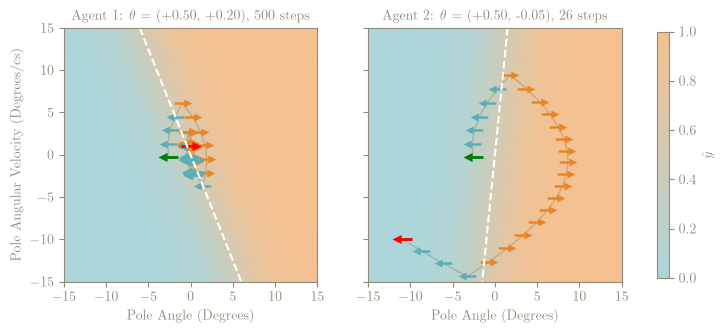

In [69]:
# --- State space: Agent 1 vs Agent 2, same seed-0 episode ---
N_STEPS   = None      # steps to plot (None for full episodes) — match the cartpole overlay
SHOW_GRID = True    # shade each agent's yhat over the state space
S         = 160     # arrow marker size

fig, (axL, axR) = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
for ax, ag, (X_ep, y_ep), name in [(axL, agent_1, episodes_A2[0], 'Agent 1'),
                                   (axR, agent_2, episodes_B2[0], 'Agent 2')]:
    n = len(X_ep) if N_STEPS is None else min(N_STEPS, len(X_ep))
    if SHOW_GRID:
        A, V, yhat_grid = compute_yhat_grid(ag)
        im = plot_yhat_grid(ax, A, V, yhat_grid, alpha=0.5)
    plot_state_space(ax, X_ep[:n], y_ep[:n], s=S)
    ax.set_title(f'{name}: $\\theta$ = ({ag.theta[0]:+.2f}, {ag.theta[1]:+.2f}), {len(y_ep)} steps', fontsize=10)
    ax.set_xlabel('Pole Angle (Degrees)')
    style_ax(ax); ax.set_box_aspect(1)

axL.set_ylabel('Pole Angular Velocity (Degrees/cs)')
if SHOW_GRID:
    cbar = fig.colorbar(im, ax=[axL, axR], label='$\\hat{y}$', shrink=0.8); style_cbar(cbar)
plt.savefig(SAVE_DIR + '/two_policies_state_space.svg')

agent_1: 65 arrows
agent_2: 26 arrows


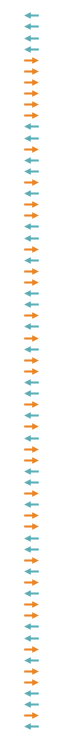

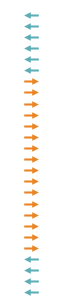

In [71]:
# --- Action columns for Agent 1 / Agent 2, tight spacing to sit beside the tables ---
N_STEPS    = 65
ROW_PITCH  = 8.0     # vertical distance between arrows, in POINTS -> match your table's line spacing in Illustrator
ARROW_SIZE = 110      # marker area (pt^2); ~sqrt -> ~10pt wide arrow
COL_W_PT   = 30.0     # column width in points
ACTION_COLORS = (LT_BLUE, ORANGE)   # (left, right) — same as the state-space plots

def draw_action_column(acts, n_steps, row_pitch_pt, col_w_pt, arrow_size, colors, save=None):
    """One left/right arrow per step, stacked top-down at a fixed pitch in points.
    Figure size is computed so bbox_inches=None keeps the pitch exact for Illustrator."""
    acts = np.asarray(acts)[:n_steps]
    n = len(acts)
    ys = -np.arange(n, dtype=float)                       # 1 data unit = one row
    fig_h_in = (n * row_pitch_pt) / 72                    # n rows tall
    fig_w_in = col_w_pt / 72
    fig = plt.figure(figsize=(fig_w_in, fig_h_in))
    ax = fig.add_axes([0, 0, 1, 1])                       # axes fill the figure -> no stray margins
    left_c, right_c = colors
    ax.scatter(np.zeros((acts==1).sum()), ys[acts==1], marker=RIGHT_ARROW, s=arrow_size, color=right_c, linewidths=0)
    ax.scatter(np.zeros((acts==0).sum()), ys[acts==0], marker=LEFT_ARROW,  s=arrow_size, color=left_c,  linewidths=0)
    ax.set_xlim(-0.5, 0.5)
    ax.set_ylim(-n + 0.5, 0.5)                            # each arrow centered in its own row
    ax.axis('off')
    if save:
        fig.savefig(SAVE_DIR + save, format='svg', transparent=True, bbox_inches=None)
    return fig, ax

for name, (X_ep, y_ep) in [('agent_1', episodes_A2[0]), ('agent_2', episodes_B2[0])]:
    draw_action_column(y_ep, N_STEPS, ROW_PITCH, COL_W_PT, ARROW_SIZE, ACTION_COLORS,
                       save=f'/two_policies_actions_{name}.svg')
    print(f'{name}: {min(N_STEPS, len(y_ep))} arrows')

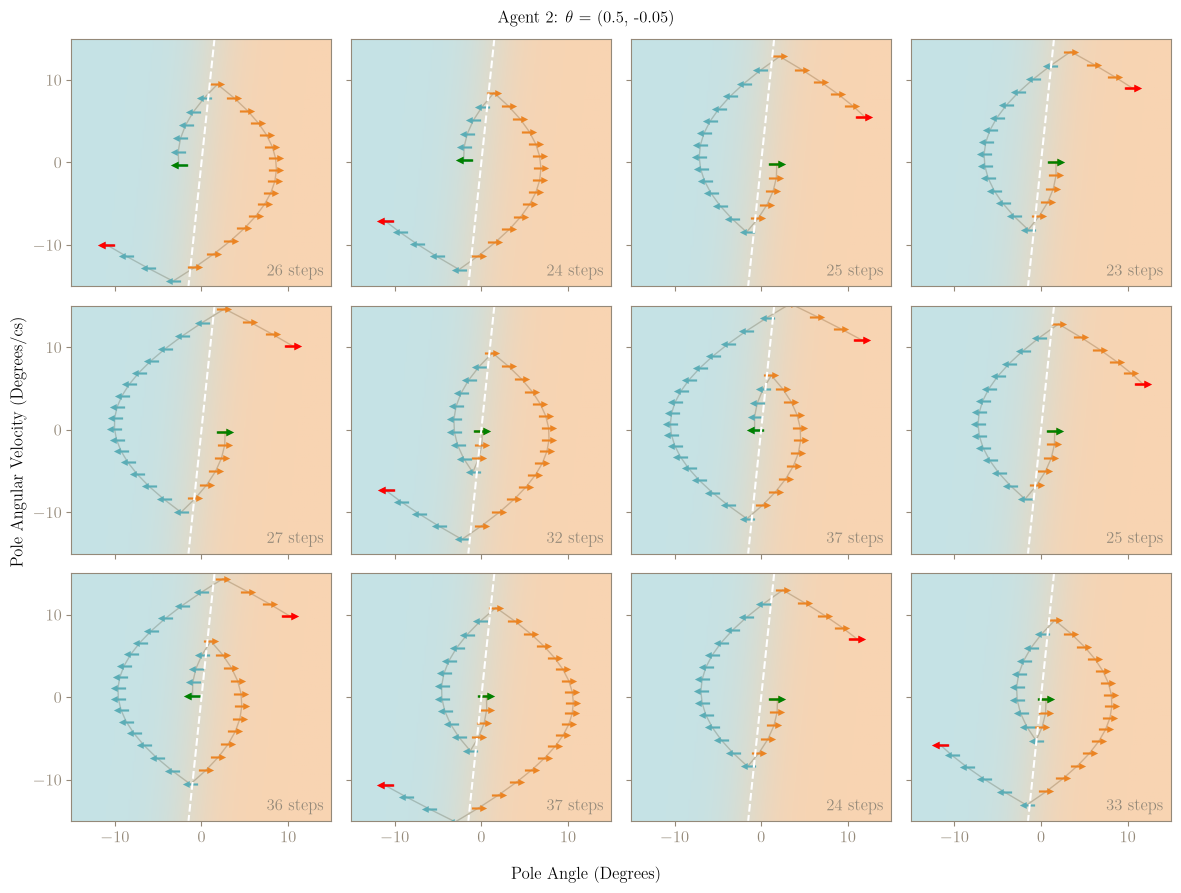

In [84]:
agent_2 = Pi()
with torch.no_grad(): agent_2.theta[:] = torch.tensor([0.5, -0.05])
episodes_B = [run_episode(agent_2, seed=i) for i in range(12)]

A, V, yhat_grid = compute_yhat_grid(agent_2)
fig, axs = plt.subplots(3, 4, figsize=(12, 9), sharex=True, sharey=True)
for ax, (X_ep, y_ep) in zip(axs.ravel(), episodes_B):
    plot_yhat_grid(ax, A, V, yhat_grid, alpha=0.35)
    plot_state_space(ax, X_ep, y_ep, s=120)
    ax.text(0.97, 0.03, f'{len(y_ep)} steps', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=12, color=CHILL_BROWN)
    ax.tick_params(labelsize=12)
    ax.set_xticks([-10, 0, 10])
    ax.set_yticks([-10, 0, 10])
    style_ax(ax)
fig.supxlabel('Pole Angle (Degrees)'); fig.supylabel('Pole Angular Velocity (Degrees/cs)')
fig.suptitle(r'Agent 2: $\theta$ = (0.5, -0.05)'); plt.tight_layout()
plt.savefig(SAVE_DIR + '/agent_2_blowing_it.svg')

In [85]:
def run_episode_stochastic(agent, env_seed, policy_seed, max_steps=500):
    """Same as run_episode, but the agent pushes right with probability yhat instead of whenever yhat >= 0.5."""
    env = gym.make("CartPole-v1")
    state, _ = env.reset(seed=env_seed)
    rng = np.random.default_rng(policy_seed)             # policy randomness, independent of the starting state
    X_ep, y_ep = [], []
    for t in range(max_steps):
        with torch.no_grad():
            features = to_features(state)
            action = int(rng.random() < agent(features))   # push right with probability yhat
        X_ep.append(features); y_ep.append(action)
        state, reward, terminated, truncated, _ = env.step(action)
        if terminated or truncated: break
    return torch.stack(X_ep), torch.tensor(y_ep)

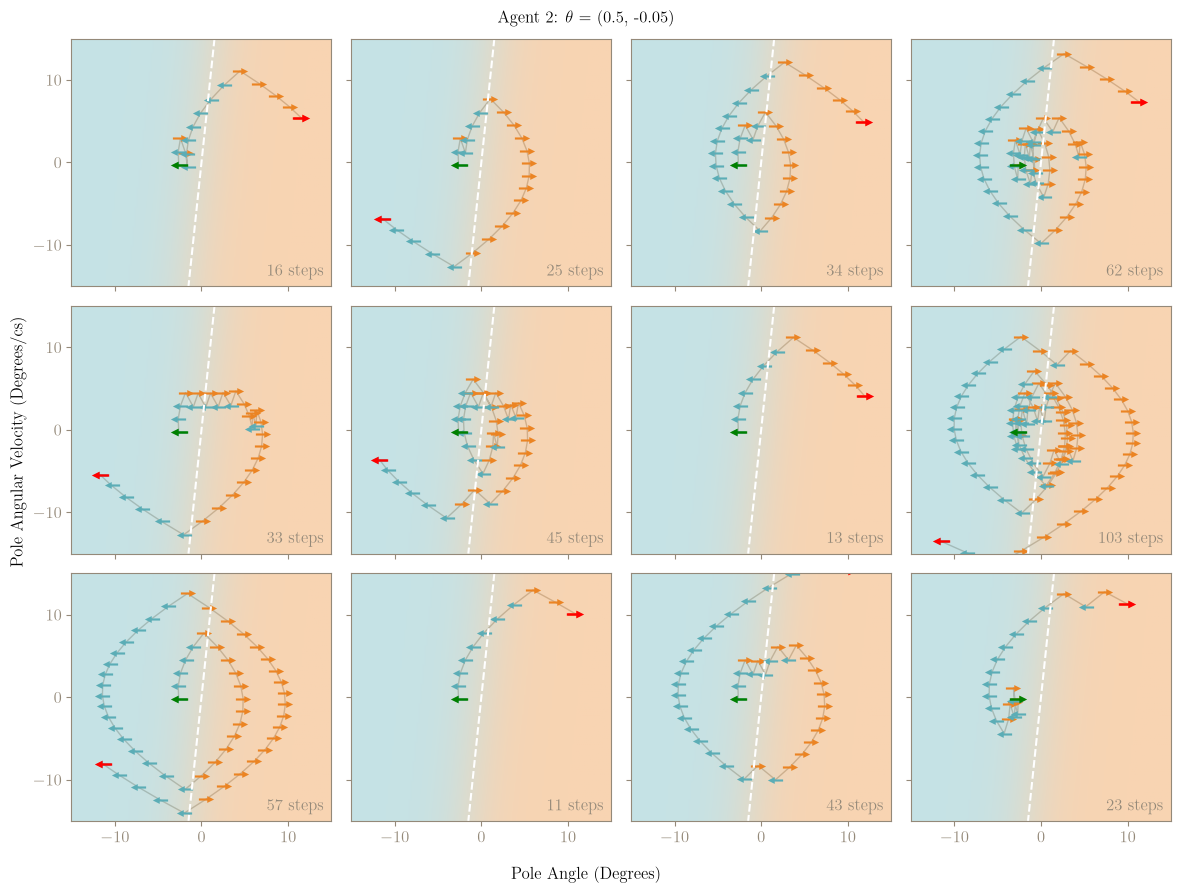

In [86]:
episodes_C = [run_episode_stochastic(agent_2, env_seed=0, policy_seed=i) for i in range(12)] #Fixed seed

A, V, yhat_grid = compute_yhat_grid(agent_2)
fig, axs = plt.subplots(3, 4, figsize=(12, 9), sharex=True, sharey=True)
for ax, (X_ep, y_ep) in zip(axs.ravel(), episodes_C):
    plot_yhat_grid(ax, A, V, yhat_grid, alpha=0.35)
    plot_state_space(ax, X_ep, y_ep, s=120)
    ax.text(0.97, 0.03, f'{len(y_ep)} steps', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=12, color=CHILL_BROWN)
    ax.tick_params(labelsize=12)
    ax.set_xticks([-10, 0, 10])
    ax.set_yticks([-10, 0, 10])
    style_ax(ax)
fig.supxlabel('Pole Angle (Degrees)'); fig.supylabel('Pole Angular Velocity (Degrees/cs)')
fig.suptitle(r'Agent 2: $\theta$ = (0.5, -0.05)'); plt.tight_layout()
plt.savefig(SAVE_DIR + '/agent_sotochastic.svg')

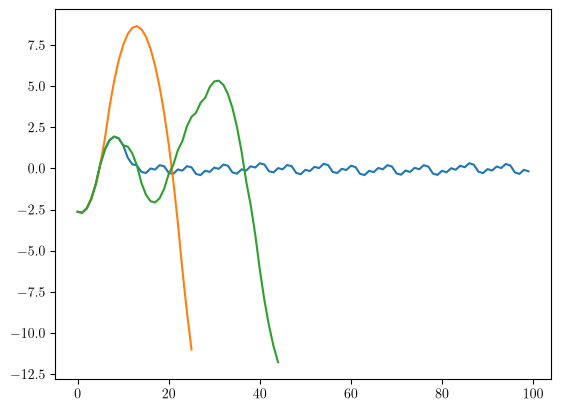

In [87]:
# plt.plot(episodes_A2[0][0][:100, 0])
# plt.plot(episodes_B2[0][0][:100, 0]) #Ok yeah a vertical timeseries plot here would be dope!
# plt.plot(episodes_C[5][0][:100, 0]) 

Now, for tables I want x1, x2, theta1, theta2, yhat, action (show with arrow in final table!)